In [1]:
from __future__ import annotations

import os
import sys
import json
import time
import traceback
import multiprocessing as mp

from collections import Counter
from concurrent.futures import ProcessPoolExecutor, as_completed
from copy import deepcopy
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from agents import DeliveryAgent, MaliciousDeliveryAgent
from model import AgentProfile, BintWorldModel, MAP_DATA_SERVICE


pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [22]:
# -------------------------------------------------------------------
# Evaluation output folders
# -------------------------------------------------------------------

OUTPUT_DIR = PROJECT_ROOT / "evaluation_outputs"
DATA_DIR = OUTPUT_DIR / "data"
FIGURE_DIR = OUTPUT_DIR / "figures"
ERROR_DIR = OUTPUT_DIR / "errors"

for directory in [OUTPUT_DIR, DATA_DIR, FIGURE_DIR, ERROR_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


# -------------------------------------------------------------------
# Performance settings
# -------------------------------------------------------------------

EVAL_SETTINGS = {
    # collect_every affects only trajectory recording
    "collect_every": 5,
    "max_workers": 4,
    "use_parallel": True,
}

MASTER_SEED = 1337

def get_evaluation_seeds(num_runs: int, base_seed: int = MASTER_SEED) -> list[int]:
    """Generates a list of independent, reproducible seeds."""
    ss = np.random.SeedSequence(base_seed)
    
    return [int(s) for s in ss.generate_state(num_runs)]


EVALUATION_SEEDS_10 = get_evaluation_seeds(10)
EVALUATION_SEEDS_15 = get_evaluation_seeds(15)
EVALUATION_SEEDS_30 = get_evaluation_seeds(30)
EVALUATION_SEEDS_50 = get_evaluation_seeds(50)
EVALUATION_SEEDS_100 = get_evaluation_seeds(100)

In [4]:
FINAL_BASE_PARAMETERS = {
    "width": 150,
    "height": 150,
    "num_drop_offs": 35,

    "honest_agents": 14,
    "malicious_agents": 6,

    "vision_radius": 2,
    "max_steps": 5_000,

    "genesis_tokens": 5,

    "trust_reject_threshold": 0.30,
    "trust_accept_threshold": 0.80,

    "context_match_weight": 1.0,
    "other_context_weight": 0.25,
    "trust_prior_active": 1.0,
    "trust_prior_burned": 1.0,
    "burned_weight_multiplier": 1.0,
    "filter_untrusted_evidence": True,

    "max_negative_review_rate": 0.60,
    "min_reviews_before_reviewer_check": 8,

    "staking_enabled": True,
    "staking_min_fraction": 0.10,
    "staking_max_fraction": 0.90,

    "provider_stake_vtp_weight": 0.8,
    "provider_stake_reviewer_weight": 0.2,
    "requester_stake_vtp_weight": 0.4,
    "requester_stake_reviewer_weight": 0.6,

    "false_map_probability": 0.50,
    "false_negative_review_probability": 0.50,
    "false_positive_review_probability": 0.50,
}


def make_config(**overrides: Any) -> dict[str, Any]:
    config = deepcopy(FINAL_BASE_PARAMETERS)
    config.update(overrides)
    return config


def show_config(config: dict[str, Any]) -> pd.DataFrame:
    return pd.DataFrame(
        [{"parameter": key, "value": value} for key, value in config.items()]
    )


LOCKED_BASE_CONFIG = make_config()

In [5]:
def _common_agent_kwargs(config: dict[str, Any]) -> dict[str, Any]:
    return {
        "vision_radius": config["vision_radius"],
        "trust_reject_threshold": config["trust_reject_threshold"],
        "trust_accept_threshold": config["trust_accept_threshold"],
        "max_negative_review_rate": config["max_negative_review_rate"],
        "min_reviews_before_reviewer_check": config["min_reviews_before_reviewer_check"],
        "context_match_weight": config["context_match_weight"],
        "other_context_weight": config["other_context_weight"],
        "trust_prior_active": config["trust_prior_active"],
        "trust_prior_burned": config["trust_prior_burned"],
        "burned_weight_multiplier": config["burned_weight_multiplier"],
        "filter_untrusted_evidence": config["filter_untrusted_evidence"],
        "staking_min_fraction": config["staking_min_fraction"],
        "staking_max_fraction": config["staking_max_fraction"],
        "provider_stake_vtp_weight": config["provider_stake_vtp_weight"],
        "provider_stake_reviewer_weight": config["provider_stake_reviewer_weight"],
        "requester_stake_vtp_weight": config["requester_stake_vtp_weight"],
        "requester_stake_reviewer_weight": config["requester_stake_reviewer_weight"],
    }


def make_agent_profiles(config: dict[str, Any]) -> list[AgentProfile]:
    profiles: list[AgentProfile] = []

    honest_count = int(config["honest_agents"])
    malicious_count = int(config["malicious_agents"])

    if honest_count > 0:
        profiles.append(
            AgentProfile(
                agent_class=DeliveryAgent,
                count=honest_count,
                kwargs=_common_agent_kwargs(config),
            )
        )

    if malicious_count > 0:
        malicious_kwargs = _common_agent_kwargs(config)
        malicious_kwargs.update(
            {
                "false_map_probability": config["false_map_probability"],
                "false_negative_review_probability": config["false_negative_review_probability"],
                "false_positive_review_probability": config["false_positive_review_probability"],
            }
        )

        profiles.append(
            AgentProfile(
                agent_class=MaliciousDeliveryAgent,
                count=malicious_count,
                kwargs=malicious_kwargs,
            )
        )

    return profiles


def make_model(config: dict[str, Any], seed: int) -> BintWorldModel:
    return BintWorldModel(
        rng=seed,
        width=int(config["width"]),
        height=int(config["height"]),
        num_drop_offs=int(config["num_drop_offs"]),
        genesis_tokens=int(config["genesis_tokens"]),
        max_steps=int(config["max_steps"]),
        staking_enabled=bool(config["staking_enabled"]),
        agent_profiles=make_agent_profiles(config),
    )

In [6]:
def agent_kind(agent: DeliveryAgent) -> str:
    return "malicious" if isinstance(agent, MaliciousDeliveryAgent) else "honest"


def agent_type_map(model: BintWorldModel) -> dict[str, str]:
    return {
        agent.unique_id: agent_kind(agent)
        for agent in model.cached_delivery_agents
    }


def safe_trust_score(model: BintWorldModel, agent: DeliveryAgent) -> float:
    try:
        return float(model.get_vtp_summary(agent.unique_id, MAP_DATA_SERVICE)["score"])
    except Exception:
        return float("nan")


def safe_mean(values: list[float]) -> float:
    values = [value for value in values if pd.notna(value)]
    return sum(values) / len(values) if values else 0.0


def safe_div(num, den):
    return np.where(den > 0, num / den, np.nan)

In [7]:
def ledger_counts_by_owner_type(model: BintWorldModel) -> dict[str, int]:
    kinds = agent_type_map(model)
    counts: Counter[str] = Counter()

    for tnft in model.tnft_ledger:
        owner_kind = kinds.get(tnft.get("owner"), "unknown")
        is_active = bool(tnft.get("status"))
        is_staked = is_active and tnft.get("staked_for") is not None

        if is_active:
            counts[f"active_tnfts_{owner_kind}"] += 1
        else:
            counts[f"burned_tnfts_{owner_kind}"] += 1

        if is_staked:
            counts[f"staked_tnfts_{owner_kind}"] += 1

    return dict(counts)


def interaction_counts(model: BintWorldModel) -> dict[str, Any]:
    kinds = agent_type_map(model)
    counts: Counter[str] = Counter()

    truster_stake_requested = 0
    trustee_stake_requested = 0
    truster_stake_locked = 0
    trustee_stake_locked = 0

    provider_required_sum = 0
    requester_required_sum = 0
    provider_limit_sum = 0
    requester_limit_sum = 0

    for interaction in model.interactions.values():
        trustee_kind = kinds.get(interaction.trustee_id, "unknown")
        truster_kind = kinds.get(interaction.truster_id, "unknown")

        counts[f"interactions_trustee_{trustee_kind}"] += 1
        counts[f"interactions_truster_{truster_kind}"] += 1
        counts[f"interactions_status_{interaction.status}"] += 1

        meta = interaction.meta or {}

        truster_stake_requested += int(meta.get("truster_stake_requested", 0) or 0)
        trustee_stake_requested += int(meta.get("trustee_stake_requested", 0) or 0)
        truster_stake_locked += int(meta.get("truster_stake_locked", 0) or 0)
        trustee_stake_locked += int(meta.get("trustee_stake_locked", 0) or 0)

        provider_required_sum += int(meta.get("provider_stake_required", 0) or 0)
        requester_required_sum += int(meta.get("requester_stake_required", 0) or 0)

        provider_limit_sum += int(
            meta.get("provider_stake_limit", meta.get("provider_stake_offer", 0)) or 0
        )
        requester_limit_sum += int(
            meta.get("requester_stake_limit", meta.get("requester_stake_offer", 0)) or 0
        )

    total_interactions = len(model.interactions)

    result = dict(counts)
    result.update(
        {
            "interactions": total_interactions,
            "accepted_malicious_provider": counts.get("interactions_trustee_malicious", 0),
            "accepted_honest_provider": counts.get("interactions_trustee_honest", 0),
            "truster_stake_requested_sum": truster_stake_requested,
            "trustee_stake_requested_sum": trustee_stake_requested,
            "truster_stake_locked_sum": truster_stake_locked,
            "trustee_stake_locked_sum": trustee_stake_locked,
            "provider_stake_required_sum": provider_required_sum,
            "requester_stake_required_sum": requester_required_sum,
            "provider_stake_limit_or_offer_sum": provider_limit_sum,
            "requester_stake_limit_or_offer_sum": requester_limit_sum,
            "avg_provider_required_stake": (
                provider_required_sum / total_interactions if total_interactions else 0.0
            ),
            "avg_requester_required_stake": (
                requester_required_sum / total_interactions if total_interactions else 0.0
            ),
        }
    )

    return result


def outcome_counts(model: BintWorldModel) -> dict[str, Any]:
    counts: Counter[str] = Counter()

    for outcome in model.outcomes.values():
        counts[f"outcome_{outcome.status}"] += 1

        meta = outcome.meta or {}

        review_mode = meta.get("review_mode")
        if review_mode:
            counts[f"review_mode_{review_mode}"] += 1

        actual = meta.get("actual_outcome_status")
        reported = meta.get("reported_outcome_status")

        if actual:
            counts[f"actual_outcome_{actual}"] += 1

        if reported:
            counts[f"reported_outcome_{reported}"] += 1

        if meta.get("review_was_false"):
            counts["false_reviews"] += 1

    return dict(counts)


def reviewer_counts(model: BintWorldModel) -> dict[str, Any]:
    kinds = agent_type_map(model)
    counts: Counter[str] = Counter()

    for agent in model.cached_delivery_agents:
        kind = kinds.get(agent.unique_id, "unknown")
        summary = model.get_reviewer_summary(agent.unique_id)

        counts[f"reviews_{kind}"] += int(summary["total_reviews"])
        counts[f"negative_reviews_{kind}"] += int(summary["negative_reviews"])

    result = dict(counts)

    for kind in ("honest", "malicious"):
        total = counts.get(f"reviews_{kind}", 0)
        neg = counts.get(f"negative_reviews_{kind}", 0)
        result[f"negative_review_rate_{kind}"] = neg / total if total else 0.0

    return result


def decision_counts(model: BintWorldModel) -> dict[str, int]:
    if hasattr(model, "decision_events"):
        events = getattr(model, "decision_events")
        counter = Counter(event.get("reason", "none") for event in events)
        return {f"decision_{reason}": count for reason, count in counter.items()}

    counter = Counter(
        getattr(agent, "last_decision_reason", "none")
        for agent in model.cached_delivery_agents
    )

    return {f"latest_decision_{reason}": count for reason, count in counter.items()}

In [8]:
def collect_metrics(
    model: BintWorldModel,
    *,
    config_name: str,
    seed: int,
    sim_step: int,
) -> dict[str, Any]:
    agents = list(model.cached_delivery_agents)

    honest_agents = [
        agent for agent in agents
        if agent_kind(agent) == "honest"
    ]

    malicious_agents = [
        agent for agent in agents
        if agent_kind(agent) == "malicious"
    ]

    trust_honest = [safe_trust_score(model, agent) for agent in honest_agents]
    trust_malicious = [safe_trust_score(model, agent) for agent in malicious_agents]

    active_tnfts = sum(1 for tnft in model.tnft_ledger if tnft["status"])
    burned_tnfts = sum(1 for tnft in model.tnft_ledger if not tnft["status"])

    staked_tnfts = sum(
        1
        for tnft in model.tnft_ledger
        if tnft["status"] and tnft.get("staked_for") is not None
    )

    available_tnfts = sum(
        1
        for tnft in model.tnft_ledger
        if tnft["status"] and tnft.get("staked_for") is None
    )

    row: dict[str, Any] = {
        "config": config_name,
        "seed": seed,
        "sim_step": sim_step,
        "model_steps": getattr(model, "steps", sim_step),

        "honest_agents": len(honest_agents),
        "malicious_agents": len(malicious_agents),

        "active_tnfts": active_tnfts,
        "burned_tnfts": burned_tnfts,
        "staked_tnfts": staked_tnfts,
        "available_tnfts": available_tnfts,

        "total_deliveries": sum(agent.delivery_count for agent in agents),
        "deliveries_honest": sum(agent.delivery_count for agent in honest_agents),
        "deliveries_malicious": sum(agent.delivery_count for agent in malicious_agents),

        "total_points": sum(agent.points for agent in agents),
        "points_honest": sum(agent.points for agent in honest_agents),
        "points_malicious": sum(agent.points for agent in malicious_agents),

        "avg_trust_honest": safe_mean(trust_honest),
        "avg_trust_malicious": safe_mean(trust_malicious),
        "trust_gap_honest_minus_malicious": (
            safe_mean(trust_honest) - safe_mean(trust_malicious)
        ),
    }

    row.update(ledger_counts_by_owner_type(model))
    row.update(interaction_counts(model))
    row.update(outcome_counts(model))
    row.update(reviewer_counts(model))
    row.update(decision_counts(model))

    return row

In [9]:
def run_one(
    config: dict[str, Any],
    *,
    config_name: str,
    seed: int,
    collect_every: int = 100,
    verbose: bool = False,
) -> pd.DataFrame:
    model = make_model(config, seed)
    max_steps = int(config["max_steps"])

    rows: list[dict[str, Any]] = [
        collect_metrics(
            model,
            config_name=config_name,
            seed=seed,
            sim_step=0,
        )
    ]

    start_time = time.time()

    for step in range(1, max_steps + 1):
        model.step()

        if step % collect_every == 0 or step == max_steps:
            rows.append(
                collect_metrics(
                    model,
                    config_name=config_name,
                    seed=seed,
                    sim_step=step,
                )
            )

    trajectory = pd.DataFrame(rows)
    trajectory["runtime_seconds"] = time.time() - start_time

    if verbose:
        print(
            f"Finished {config_name}, seed={seed}, "
            f"steps={max_steps}, runtime={trajectory['runtime_seconds'].iloc[-1]:.2f}s"
        )

    return trajectory


def final_from_trajectory(trajectory_df: pd.DataFrame) -> pd.DataFrame:
    return (
        trajectory_df
        .sort_values(["config", "seed", "sim_step"])
        .groupby(["config", "seed"], as_index=False)
        .tail(1)
        .reset_index(drop=True)
    )


def run_batch_serial(
    configs: list[tuple[str, dict[str, Any]]],
    seeds: list[int],
    *,
    collect_every: int = 100,
    continue_on_error: bool = True,
    verbose: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    trajectories: list[pd.DataFrame] = []
    errors: list[dict[str, Any]] = []

    total = len(configs) * len(seeds)
    completed = 0

    for config_name, config in configs:
        for seed in seeds:
            completed += 1

            if verbose:
                print(f"[{completed}/{total}] Running {config_name}, seed={seed}")

            try:
                trajectory = run_one(
                    config,
                    config_name=config_name,
                    seed=seed,
                    collect_every=collect_every,
                    verbose=False,
                )
                trajectories.append(trajectory)

            except Exception as exc:
                error_info = {
                    "config": config_name,
                    "seed": seed,
                    "error": repr(exc),
                    "traceback": traceback.format_exc(),
                }
                errors.append(error_info)

                if not continue_on_error:
                    raise

                print(f"ERROR in {config_name}, seed={seed}: {exc}")

    if not trajectories:
        raise RuntimeError("No successful runs.")

    trajectory_df = (
        pd.concat(trajectories, ignore_index=True, sort=False)
        .fillna(0)
    )

    final_df = final_from_trajectory(trajectory_df)

    if errors:
        error_df = pd.DataFrame(errors)
        error_path = ERROR_DIR / "evaluation_run_errors.csv"
        error_df.to_csv(error_path, index=False)
        print(f"Saved errors to {error_path}")

    return trajectory_df, final_df

In [10]:
def _run_one_worker(args: tuple[str, dict[str, Any], int, int]) -> tuple[pd.DataFrame, pd.DataFrame]:
    config_name, config, seed, collect_every = args

    trajectory_df = run_one(
        config,
        config_name=config_name,
        seed=seed,
        collect_every=collect_every,
        verbose=False,
    )

    final_df = final_from_trajectory(trajectory_df)

    return trajectory_df, final_df


def run_batch_parallel(
    configs: list[tuple[str, dict[str, Any]]],
    seeds: list[int],
    *,
    collect_every: int = 100,
    max_workers: int = 4,
    continue_on_error: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    tasks = [
        (config_name, config, seed, collect_every)
        for config_name, config in configs
        for seed in seeds
    ]

    if not tasks:
        return pd.DataFrame(), pd.DataFrame()

    ctx = mp.get_context("fork")

    trajectory_parts: list[pd.DataFrame] = []
    final_parts: list[pd.DataFrame] = []
    errors: list[dict[str, Any]] = []

    start_time = time.time()

    with ProcessPoolExecutor(
        max_workers=max_workers,
        mp_context=ctx,
    ) as executor:
        future_to_task = {
            executor.submit(_run_one_worker, task): task
            for task in tasks
        }

        total = len(future_to_task)
        completed = 0

        pbar = tqdm(total=total, desc=f"Running {total} simulations") if tqdm is not None else None

        try:
            for future in as_completed(future_to_task):
                config_name, _config, seed, _collect_every = future_to_task[future]

                try:
                    trajectory_df, final_df = future.result()
                    trajectory_parts.append(trajectory_df)
                    final_parts.append(final_df)

                except Exception as exc:
                    error_info = {
                        "config": config_name,
                        "seed": seed,
                        "error": repr(exc),
                        "traceback": traceback.format_exc(),
                    }
                    errors.append(error_info)

                    if not continue_on_error:
                        raise

                    print(f"ERROR in {config_name}, seed={seed}: {exc}")

                completed += 1

                if pbar is not None:
                    pbar.update(1)
                elif completed % 5 == 0 or completed == total:
                    print(f"Completed {completed}/{total} simulations")

        finally:
            if pbar is not None:
                pbar.close()

    if not trajectory_parts:
        raise RuntimeError("No successful runs.")

    trajectory_df = (
        pd.concat(trajectory_parts, ignore_index=True, sort=False)
        .fillna(0)
    )

    final_df = (
        pd.concat(final_parts, ignore_index=True, sort=False)
        .fillna(0)
    )

    elapsed = time.time() - start_time

    print(
        f"Finished {len(tasks)} simulations with {max_workers} workers "
        f"in {elapsed:.1f} seconds."
    )

    if errors:
        error_df = pd.DataFrame(errors)
        error_path = ERROR_DIR / "evaluation_parallel_errors.csv"
        error_df.to_csv(error_path, index=False)
        print(f"Saved errors to {error_path}")

    return trajectory_df, final_df


def run_batch_auto(
    configs: list[tuple[str, dict[str, Any]]],
    seeds: list[int],
    *,
    collect_every: int | None = None,
    use_parallel: bool | None = None,
    max_workers: int | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    collect_every = collect_every or EVAL_SETTINGS["collect_every"]
    use_parallel = EVAL_SETTINGS["use_parallel"] if use_parallel is None else use_parallel
    max_workers = max_workers or EVAL_SETTINGS["max_workers"]

    if use_parallel:
        return run_batch_parallel(
            configs,
            seeds,
            collect_every=collect_every,
            max_workers=max_workers,
        )

    return run_batch_serial(
        configs,
        seeds,
        collect_every=collect_every,
    )

In [24]:
def add_parameter_selection_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "total_delivery_agents" not in df.columns:
        if {"honest_agents", "malicious_agents"}.issubset(df.columns):
            df["total_delivery_agents"] = df["honest_agents"] + df["malicious_agents"]

    if {"total_deliveries", "total_delivery_agents"}.issubset(df.columns):
        df["deliveries_per_agent"] = safe_div(
            df["total_deliveries"],
            df["total_delivery_agents"],
        )

    if {"interactions", "total_delivery_agents"}.issubset(df.columns):
        df["interactions_per_agent"] = safe_div(
            df["interactions"],
            df["total_delivery_agents"],
        )

    if {"accepted_malicious_provider", "interactions"}.issubset(df.columns):
        df["accepted_malicious_provider_rate"] = safe_div(
            df["accepted_malicious_provider"],
            df["interactions"],
        )

    if {"outcome_failure", "interactions"}.issubset(df.columns):
        df["failure_rate"] = safe_div(
            df["outcome_failure"],
            df["interactions"],
        )

    if {"outcome_success", "interactions"}.issubset(df.columns):
        df["success_rate"] = safe_div(
            df["outcome_success"],
            df["interactions"],
        )

    if {"burned_tnfts_honest", "honest_agents"}.issubset(df.columns):
        df["honest_burns_per_honest_agent"] = safe_div(
            df["burned_tnfts_honest"],
            df["honest_agents"],
        )

    if {"burned_tnfts_malicious", "malicious_agents"}.issubset(df.columns):
        df["malicious_burns_per_malicious_agent"] = safe_div(
            df["burned_tnfts_malicious"],
            df["malicious_agents"],
        )

    if {"burned_tnfts_honest", "burned_tnfts_malicious"}.issubset(df.columns):
        total_group_burns = df["burned_tnfts_honest"] + df["burned_tnfts_malicious"]
        df["malicious_burn_share"] = safe_div(
            df["burned_tnfts_malicious"],
            total_group_burns,
        )

    if {"staked_tnfts", "active_tnfts"}.issubset(df.columns):
        df["staked_to_active_ratio"] = safe_div(
            df["staked_tnfts"],
            df["active_tnfts"],
        )

    return df


def add_staking_diagnostics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    stake_rejection_patterns = ["no_available_stake", "insufficient_stake", "stake_limit", "stake_lock_failed"]
    trust_rejection_patterns = ["low_vtp", "low_reviewer_credibility"]

    # Look for both potential prefixes to ensure safety
    stake_rejection_cols = [
        col for col in df.columns
        if (col.startswith("decision_") or col.startswith("latest_decision_"))
        and any(pattern in col for pattern in stake_rejection_patterns)
    ]

    trust_rejection_cols = [
        col for col in df.columns
        if (col.startswith("decision_") or col.startswith("latest_decision_"))
        and any(pattern in col for pattern in trust_rejection_patterns)
    ]

    accepted_cols = [
        col for col in df.columns
        if col in {"decision_provider_accepted", "decision_requester_accepted", 
                  "latest_decision_provider_accepted", "latest_decision_requester_accepted"}
    ]

    df["stake_rejections"] = df[stake_rejection_cols].sum(axis=1) if stake_rejection_cols else 0
    df["trust_rejections"] = df[trust_rejection_cols].sum(axis=1) if trust_rejection_cols else 0
    df["accepted_decisions"] = df[accepted_cols].sum(axis=1) if accepted_cols else 0

    if "interactions" in df.columns:
        df["stake_rejections_per_interaction"] = safe_div(df["stake_rejections"], df["interactions"])
        df["trust_rejections_per_interaction"] = safe_div(df["trust_rejections"], df["interactions"])

    if {"avg_provider_required_stake", "avg_requester_required_stake"}.issubset(df.columns):
        df["avg_total_required_stake"] = df["avg_provider_required_stake"] + df["avg_requester_required_stake"]

    return df
    

def add_point_selection_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "total_delivery_agents" not in df.columns:
        if {"honest_agents", "malicious_agents"}.issubset(df.columns):
            df["total_delivery_agents"] = df["honest_agents"] + df["malicious_agents"]

    if {"total_points", "total_delivery_agents"}.issubset(df.columns):
        df["points_per_agent"] = safe_div(
            df["total_points"],
            df["total_delivery_agents"],
        )

    if {"points_honest", "honest_agents"}.issubset(df.columns):
        df["points_per_honest_agent"] = safe_div(
            df["points_honest"],
            df["honest_agents"],
        )

    if {"points_malicious", "malicious_agents"}.issubset(df.columns):
        df["points_per_malicious_agent"] = safe_div(
            df["points_malicious"],
            df["malicious_agents"],
        )

    if {"total_points", "total_deliveries"}.issubset(df.columns):
        df["points_per_delivery"] = safe_div(
            df["total_points"],
            df["total_deliveries"],
        )

    if {"points_honest", "deliveries_honest"}.issubset(df.columns):
        df["honest_points_per_delivery"] = safe_div(
            df["points_honest"],
            df["deliveries_honest"],
        )

    if {"points_malicious", "deliveries_malicious"}.issubset(df.columns):
        df["malicious_points_per_delivery"] = safe_div(
            df["points_malicious"],
            df["deliveries_malicious"],
        )

    if {"points_per_honest_agent", "points_per_malicious_agent"}.issubset(df.columns):
        df["points_gap_honest_minus_malicious"] = (
            df["points_per_honest_agent"]
            - df["points_per_malicious_agent"]
        )

    return df


def add_all_derived_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = add_parameter_selection_metrics(df)
    df = add_staking_diagnostics(df)
    df = add_point_selection_metrics(df)
    return df

def analyze_steady_state(trajectory_df: pd.DataFrame, 
                         metric: str, 
                         lookback_steps: int = 1000, 
                         cv_threshold: float = 0.05) -> pd.DataFrame:
    """
    Analyzes whether the simulation reached a steady state over its final steps.
    
    Args:
        trajectory_df: DataFrame containing the time-series trajectory of the simulation.
        metric: The column name of the metric to analyze (e.g., 'failure_rate', 'trust_rejections').
        lookback_steps: How many steps from the end of the simulation to evaluate.
        cv_threshold: The maximum Coefficient of Variation allowed to consider it 'converged' (default 5%).
    """
    if metric not in trajectory_df.columns:
        print(f"Metric '{metric}' not found in DataFrame columns.")
        return pd.DataFrame()
        
    max_step = trajectory_df["sim_step"].max()
    start_step = max_step - lookback_steps
    
    window_df = trajectory_df[trajectory_df["sim_step"] >= start_step]
    
    grouped = window_df.groupby(["config", "seed"])[metric].agg(["mean", "std"]).reset_index()
    
    grouped["cv"] = grouped["std"] / (grouped["mean"].abs() + 1e-9)
    
    stability_summary = grouped.groupby("config").agg(
        window_mean=(metric, "mean"),
        window_std=("std", "mean"),
        avg_cv=("cv", "mean")
    ).reset_index()
    
    stability_summary["is_converged"] = stability_summary["avg_cv"] <= cv_threshold
    
    print(f"--- Steady State Analysis for '{metric}' (Last {lookback_steps} Steps) ---")
    return stability_summary.round(4)

In [12]:
CORE_FINAL_METRICS = [
    "deliveries_per_agent",
    "points_per_agent",
    "points_per_delivery",
    "interactions_per_agent",
    "accepted_malicious_provider_rate",
    "failure_rate",
    "trust_gap_honest_minus_malicious",
    "avg_trust_honest",
    "avg_trust_malicious",
    "honest_burns_per_honest_agent",
    "malicious_burns_per_malicious_agent",
    "malicious_burn_share",
    "stake_rejections_per_interaction",
]


def summarize_final_metrics(
    final_df: pd.DataFrame,
    metrics: list[str] | None = None,
) -> pd.DataFrame:
    metrics = metrics or CORE_FINAL_METRICS

    available_metrics = [
        metric for metric in metrics
        if metric in final_df.columns
    ]

    return (
        final_df
        .groupby("config")[available_metrics]
        .agg(["mean", "std", "min", "max"])
        .round(3)
    )


def show_run_sizes(
    trajectory_df: pd.DataFrame,
    final_df: pd.DataFrame,
) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "trajectory_rows": len(trajectory_df),
                "final_rows": len(final_df),
                "num_configs": final_df["config"].nunique() if "config" in final_df else 0,
                "num_seeds": final_df["seed"].nunique() if "seed" in final_df else 0,
            }
        ]
    )

In [13]:
def save_dataframe(df: pd.DataFrame, path_without_suffix: Path) -> Path:
    """
    Save as parquet when possible, otherwise CSV.
    Returns the path actually written.
    """
    path_without_suffix.parent.mkdir(parents=True, exist_ok=True)

    parquet_path = path_without_suffix.with_suffix(".parquet")
    csv_path = path_without_suffix.with_suffix(".csv")

    try:
        df.to_parquet(parquet_path, index=False)
        return parquet_path
    except Exception as exc:
        print(f"Could not save parquet because: {exc}")
        df.to_csv(csv_path, index=False)
        return csv_path


def load_dataframe(path: Path) -> pd.DataFrame:
    if path.suffix == ".parquet":
        return pd.read_parquet(path)

    if path.suffix == ".csv":
        return pd.read_csv(path)

    raise ValueError(f"Unsupported file type: {path}")


def save_run_outputs(
    *,
    run_name: str,
    trajectory_df: pd.DataFrame,
    final_df: pd.DataFrame,
    configs: list[tuple[str, dict[str, Any]]],
    seeds: list[int],
    settings: dict[str, Any] | None = None,
) -> dict[str, Path]:
    run_dir = DATA_DIR / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    trajectory_path = save_dataframe(
        trajectory_df,
        run_dir / f"{run_name}_trajectory",
    )

    final_path = save_dataframe(
        final_df,
        run_dir / f"{run_name}_final",
    )

    metadata = {
        "run_name": run_name,
        "created_at_unix": time.time(),
        "configs": [
            {
                "name": config_name,
                "config": config,
            }
            for config_name, config in configs
        ],
        "seeds": seeds,
        "settings": settings or EVAL_SETTINGS,
    }

    metadata_path = run_dir / f"{run_name}_metadata.json"

    with metadata_path.open("w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved trajectory: {trajectory_path}")
    print(f"Saved final:      {final_path}")
    print(f"Saved metadata:   {metadata_path}")

    return {
        "trajectory": trajectory_path,
        "final": final_path,
        "metadata": metadata_path,
    }

In [23]:
from scipy import stats

def verify_ablation_significance(final_df: pd.DataFrame, metric: str = "failure_rate"):
    """Performs a t-test between trust-only and trust+staking (BINT) configurations."""
    staking_data = final_df[final_df["config"] == "bint_staking_medium_attack"][metric]
    no_staking_data = final_df[final_df["config"] == "trust_no_staking_medium_attack"][metric]
    
    if len(staking_data) > 0 and len(no_staking_data) > 0:
        t_stat, p_val = stats.ttest_ind(staking_data, no_staking_data, equal_var=False)
        print(f"--- Welch's T-Test for {metric} ---")
        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {p_val:.4e}")
        if p_val < 0.05:
            print("Conclusion: The difference is statistically SIGNIFICANT (p < 0.05).")
        else:
            print("Conclusion: The difference is NOT statistically significant.")

In [14]:
def save_current_figure(filename: str) -> Path:
    path = FIGURE_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to: {path}")
    return path


def plot_time_metric(
    trajectory_df: pd.DataFrame,
    metric: str,
    *,
    title: str | None = None,
    ylabel: str | None = None,
    save_as: str | None = None,
) -> None:
    if metric not in trajectory_df.columns:
        raise KeyError(f"Metric not found: {metric}")

    grouped = (
        trajectory_df
        .groupby(["config", "sim_step"], as_index=False)[metric]
        .mean()
        .sort_values(["config", "sim_step"])
    )

    fig, ax = plt.subplots(figsize=(9, 5))

    for config_name, config_df in grouped.groupby("config"):
        ax.plot(
            config_df["sim_step"],
            config_df[metric],
            label=config_name,
        )

    ax.set_title(title or metric)
    ax.set_xlabel("Simulation step")
    ax.set_ylabel(ylabel or metric)
    ax.legend()
    fig.tight_layout()

    if save_as:
        save_current_figure(save_as)

    plt.show()


def plot_final_metric(
    final_df: pd.DataFrame,
    metric: str,
    *,
    title: str | None = None,
    ylabel: str | None = None,
    save_as: str | None = None,
) -> None:
    if metric not in final_df.columns:
        raise KeyError(f"Metric not found: {metric}")

    fig, ax = plt.subplots(figsize=(9, 5))

    final_df.boxplot(
        column=metric,
        by="config",
        ax=ax,
        rot=30,
    )

    ax.set_title(title or metric)
    ax.set_xlabel("Configuration")
    ax.set_ylabel(ylabel or metric)

    fig.suptitle("")
    fig.tight_layout()

    if save_as:
        save_current_figure(save_as)

    plt.show()


def plot_core_dashboard(
    trajectory_df: pd.DataFrame,
    final_df: pd.DataFrame,
) -> None:
    time_metrics = [
        "total_deliveries",
        "total_points",
        "interactions",
        "avg_trust_honest",
        "avg_trust_malicious",
        "burned_tnfts",
        "staked_tnfts",
    ]

    for metric in time_metrics:
        if metric in trajectory_df.columns:
            plot_time_metric(trajectory_df, metric)

    final_metrics = [
        "deliveries_per_agent",
        "points_per_agent",
        "interactions_per_agent",
        "accepted_malicious_provider_rate",
        "failure_rate",
        "trust_gap_honest_minus_malicious",
    ]

    for metric in final_metrics:
        if metric in final_df.columns:
            plot_final_metric(final_df, metric)

In [15]:
def make_named_config(
    name: str,
    **overrides: Any,
) -> tuple[str, dict[str, Any]]:
    return name, make_config(**overrides)


def apply_attack_level(
    attack_probability: float,
    **extra_overrides: Any,
) -> dict[str, Any]:
    return make_config(
        false_map_probability=attack_probability,
        false_negative_review_probability=attack_probability,
        false_positive_review_probability=attack_probability,
        **extra_overrides,
    )


def describe_configs(configs: list[tuple[str, dict[str, Any]]]) -> pd.DataFrame:
    rows = []

    for name, config in configs:
        row = {"config": name}
        row.update(config)
        rows.append(row)

    return pd.DataFrame(rows)

In [16]:
def add_labels(
    df: pd.DataFrame,
    *,
    labels: dict[str, str],
    order: list[str],
    source_col: str = "config",
    label_col: str = "scenario_label",
) -> pd.DataFrame:
    df = df.copy()

    ordered_labels = [
        labels.get(name, name)
        for name in order
    ]

    df[label_col] = df[source_col].map(labels).fillna(df[source_col])

    # Include unexpected labels at the end instead of turning them into NaN.
    unexpected_labels = [
        label for label in df[label_col].unique()
        if label not in ordered_labels
    ]

    df[label_col] = pd.Categorical(
        df[label_col],
        categories=ordered_labels + list(unexpected_labels),
        ordered=True,
    )

    return df.sort_values(label_col)

In [20]:
def add_scenario_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["scenario_label"] = df["config"].map(SCENARIO_LABELS).fillna(df["config"])
    df["scenario_label"] = pd.Categorical(
        df["scenario_label"],
        categories=[SCENARIO_LABELS[name] for name in SCENARIO_ORDER],
        ordered=True,
    )
    return df.sort_values("scenario_label")

## Points analysis: task performance and reward distribution

This first evaluation block asks:

**How does BINT affect task performance and reward distribution under malicious map-sharing behavior?**

The goal is not simply to maximize total points. A weaker system may allow more unrestricted activity and therefore sometimes produce more total reward, while also allowing malicious agents to benefit. The more important question is whether BINT:

1. preserves honest-agent performance,
2. keeps delivery efficiency reasonable,
3. reduces malicious-agent rewards,
4. maintains a strong gap between honest and malicious agents.

The main metrics are:

- `points_per_honest_agent`
- `points_per_malicious_agent`
- `points_per_delivery`
- `honest_points_per_delivery`
- `malicious_points_per_delivery`
- `points_gap_honest_minus_malicious`

In [20]:
# -------------------------------------------------------------------
# Points analysis scenarios
# -------------------------------------------------------------------

POINTS_SCENARIOS = [
    (
        "honest_only_upper_bound",
        make_config(
            honest_agents=20,
            malicious_agents=0,
            staking_enabled=True,
            false_map_probability=0.0,
            false_negative_review_probability=0.0,
            false_positive_review_probability=0.0,
        ),
    ),

    (
        "no_trust_accept_all_medium_attack",
        make_config(
            honest_agents=14,
            malicious_agents=6,
            staking_enabled=False,

            trust_reject_threshold=0.0,
            trust_accept_threshold=0.01,

            max_negative_review_rate=1.0,
            min_reviews_before_reviewer_check=1_000_000,

            false_map_probability=0.50,
            false_negative_review_probability=0.50,
            false_positive_review_probability=0.50,
        ),
    ),

    (
        "trust_no_staking_medium_attack",
        make_config(
            honest_agents=14,
            malicious_agents=6,
            staking_enabled=False,

            trust_reject_threshold=0.30,
            trust_accept_threshold=0.80,
            max_negative_review_rate=0.60,
            min_reviews_before_reviewer_check=8,

            false_map_probability=0.50,
            false_negative_review_probability=0.50,
            false_positive_review_probability=0.50,
        ),
    ),

    (
        "bint_staking_medium_attack",
        make_config(
            honest_agents=14,
            malicious_agents=6,
            staking_enabled=True,
            staking_min_fraction=0.10,
            staking_max_fraction=0.90,

            trust_reject_threshold=0.30,
            trust_accept_threshold=0.80,
            max_negative_review_rate=0.60,
            min_reviews_before_reviewer_check=8,

            false_map_probability=0.50,
            false_negative_review_probability=0.50,
            false_positive_review_probability=0.50,
        ),
    ),
]

describe_configs(POINTS_SCENARIOS)

,config,width,height,num_drop_offs,honest_agents,malicious_agents,vision_radius,max_steps,genesis_tokens,trust_reject_threshold,trust_accept_threshold,context_match_weight,other_context_weight,trust_prior_active,trust_prior_burned,burned_weight_multiplier,filter_untrusted_evidence,max_negative_review_rate,min_reviews_before_reviewer_check,staking_enabled,staking_min_fraction,staking_max_fraction,provider_stake_vtp_weight,provider_stake_reviewer_weight,requester_stake_vtp_weight,requester_stake_reviewer_weight,false_map_probability,false_negative_review_probability,false_positive_review_probability
0,honest_only_upper_bound,150,150,35,20,0,2,5000,5,0.3,0.80,1.0,0.25,1.0,1.0,1.0,True,0.6,8,True,0.1,0.9,0.8,0.2,0.4,0.6,0.0,0.0,0.0
1,no_trust_accept_all_medium_attack,150,150,35,14,6,2,5000,5,0.0,0.01,1.0,0.25,1.0,1.0,1.0,True,1.0,1000000,False,0.1,0.9,0.8,0.2,0.4,0.6,0.5,0.5,0.5
2,trust_no_staking_medium_attack,150,150,35,14,6,2,5000,5,0.3,0.80,1.0,0.25,1.0,1.0,1.0,True,0.6,8,False,0.1,0.9,0.8,0.2,0.4,0.6,0.5,0.5,0.5
3,bint_staking_medium_attack,150,150,35,14,6,2,5000,5,0.3,0.80,1.0,0.25,1.0,1.0,1.0,True,0.6,8,True,0.1,0.9,0.8,0.2,0.4,0.6,0.5,0.5,0.5


In [22]:
# -------------------------------------------------------------------
# Points analysis run settings
# -------------------------------------------------------------------

POINTS_RUN_NAME = "points_baseline_comparison"

POINTS_SEEDS = EVALUATION_SEEDS_30

POINTS_COLLECT_EVERY = 10
POINTS_MAX_WORKERS = 4

expected_runs = len(POINTS_SCENARIOS) * len(POINTS_SEEDS)
expected_trajectory_rows = expected_runs * ((FINAL_BASE_PARAMETERS["max_steps"] // POINTS_COLLECT_EVERY) + 1)

pd.DataFrame(
    [
        {
            "run_name": POINTS_RUN_NAME,
            "num_scenarios": len(POINTS_SCENARIOS),
            "num_seeds": len(POINTS_SEEDS),
            "expected_simulation_runs": expected_runs,
            "collect_every": POINTS_COLLECT_EVERY,
            "expected_trajectory_rows_approx": expected_trajectory_rows,
            "max_workers": POINTS_MAX_WORKERS,
        }
    ]
)

,run_name,num_scenarios,num_seeds,expected_simulation_runs,collect_every,expected_trajectory_rows_approx,max_workers
0,points_baseline_comparison,4,30,120,10,60120,4


In [ ]:
# -------------------------------------------------------------------
# Run points evaluation
# -------------------------------------------------------------------

points_trajectory_df, points_final_df = run_batch_auto(
    POINTS_SCENARIOS,
    POINTS_SEEDS,
    collect_every=POINTS_COLLECT_EVERY,
    use_parallel=True,
    max_workers=POINTS_MAX_WORKERS,
)

points_trajectory_df = add_all_derived_metrics(points_trajectory_df)
points_final_df = add_all_derived_metrics(points_final_df)

show_run_sizes(points_trajectory_df, points_final_df)

Running 120 simulations:   0%|          | 0/120 [00:00<?, ?it/s]

Finished 120 simulations with 4 workers in 742.6 seconds.


,trajectory_rows,final_rows,num_configs,num_seeds
0,60120,120,4,30


In [24]:
# -------------------------------------------------------------------
# Save points evaluation outputs
# -------------------------------------------------------------------

points_paths = save_run_outputs(
    run_name=POINTS_RUN_NAME,
    trajectory_df=points_trajectory_df,
    final_df=points_final_df,
    configs=POINTS_SCENARIOS,
    seeds=POINTS_SEEDS,
    settings={
        **EVAL_SETTINGS,
        "collect_every": POINTS_COLLECT_EVERY,
        "max_workers": POINTS_MAX_WORKERS,
        "analysis_focus": "points_task_performance",
    },
)

Saved trajectory: /home/javid/Documents/int/bint/bint/evaluation_outputs/data/points_baseline_comparison/points_baseline_comparison_trajectory.parquet
Saved final:      /home/javid/Documents/int/bint/bint/evaluation_outputs/data/points_baseline_comparison/points_baseline_comparison_final.parquet
Saved metadata:   /home/javid/Documents/int/bint/bint/evaluation_outputs/data/points_baseline_comparison/points_baseline_comparison_metadata.json


In [25]:
# -------------------------------------------------------------------
# Points-focused summary table
# -------------------------------------------------------------------

POINTS_SUMMARY_METRICS = [
    "deliveries_per_agent",
    "points_per_agent",
    "points_per_honest_agent",
    "points_per_malicious_agent",
    "points_gap_honest_minus_malicious",
    "points_per_delivery",
    "honest_points_per_delivery",
    "malicious_points_per_delivery",
    "interactions_per_agent",
    "accepted_malicious_provider_rate",
    "failure_rate",
    "trust_gap_honest_minus_malicious",
]

points_summary = summarize_final_metrics(
    points_final_df,
    metrics=POINTS_SUMMARY_METRICS,
)

display(points_summary)

deliveries_per_agent                      points_per_agent                           points_per_honest_agent                            points_per_malicious_agent  \
                                                  mean    std    min    max             mean     std      min      max                    mean      std      min      max                       mean   
config                                                                                                                                                                                                 
bint_staking_medium_attack                      39.898  8.512  22.85  52.85          347.950  90.347  182.201  484.370                 497.626  128.109  261.799  693.957                     -1.294   
honest_only_upper_bound                         69.265  4.291  60.30  80.05          682.636  42.774  596.086  789.238                 682.636   42.774  596.086  789.238                        NaN   
no_trust_accept_all_medium_attack               61.725  4.512  54.55  73.25          536.513  46.500  466.893  657.093                 531.690   49.467  448.177  669.780                    547.767   
trust_no_staking_medium_attack                  42.868  9.421  18.35  60.25          375.920  96.694  127.352  553.713                 521.913  125.265  185.684  735.003                     35.271   

                                                            points_gap_honest_minus_malicious                            points_per_delivery                      honest_points_per_delivery         \
                                      std      min      max                              mean      std      min      max                mean    std    min    max                       mean    std   
config                                                                                                                                                                                                
bint_staking_medium_attack         14.616  -26.061   39.583                           498.921  127.053  265.325  698.624               8.624  0.505  7.685  9.407                      8.927  0.461   
honest_only_upper_bound               NaN      NaN      NaN                               NaN      NaN      NaN      NaN               9.855  0.062  9.718  9.989                      9.855  0.062   
no_trust_accept_all_medium_attack  47.557  437.212  636.076                           -16.077   33.033  -77.361   43.347               8.685  0.177  8.170  8.971                      8.638  0.192   
trust_no_staking_medium_attack     58.344  -24.222  266.478                           486.643  112.452  194.442  652.484               8.684  0.496  6.940  9.345                      9.112  0.467   

                                                malicious_points_per_delivery                      interactions_per_agent                      accepted_malicious_provider_rate                       \
                                     min    max                          mean    std    min    max                   mean    std    min    max                             mean    std    min    max   
config                                                                                                                                                                                                 
bint_staking_medium_attack         8.007  9.561                        -1.321  3.603 -9.286  4.318                 13.373  1.665   9.70  16.50                            0.110  0.020  0.077  0.149   
honest_only_upper_bound            9.718  9.989                           NaN    NaN    NaN    NaN                 20.887  0.764  19.55  22.60                            0.000  0.000  0.000  0.000   
no_trust_accept_all_medium_attack  8.128  9.069                         8.789  0.262  8.240  9.295                 29.280  1.743  26.10  32.15                            0.490  0.020  0.456  0.545   
trust_no_staking_medium_attack     7.40

In [26]:
# -------------------------------------------------------------------
# Compact points table for interpretation
# -------------------------------------------------------------------

compact_points_metrics = [
    "points_per_honest_agent",
    "points_per_malicious_agent",
    "points_gap_honest_minus_malicious",
    "points_per_delivery",
    "honest_points_per_delivery",
    "malicious_points_per_delivery",
    "deliveries_per_agent",
    "failure_rate",
    "accepted_malicious_provider_rate",
]

compact_points_table = (
    points_final_df
    .groupby("config")[
        [metric for metric in compact_points_metrics if metric in points_final_df.columns]
    ]
    .mean()
    .round(3)
)

display(compact_points_table)

,points_per_honest_agent,points_per_malicious_agent,points_gap_honest_minus_malicious,points_per_delivery,honest_points_per_delivery,malicious_points_per_delivery,deliveries_per_agent,failure_rate,accepted_malicious_provider_rate
config,,,,,,,,,
bint_staking_medium_attack,497.626,-1.294,498.921,8.624,8.927,-1.321,39.898,0.100,0.110
honest_only_upper_bound,682.636,NaN,NaN,9.855,9.855,NaN,69.265,0.000,0.000
no_trust_accept_all_medium_attack,531.690,547.767,-16.077,8.685,8.638,8.789,61.725,0.349,0.490
trust_no_staking_medium_attack,521.913,35.271,486.643,8.684,9.112,1.798,42.868,0.163,0.172


Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/points_per_honest_agent.png


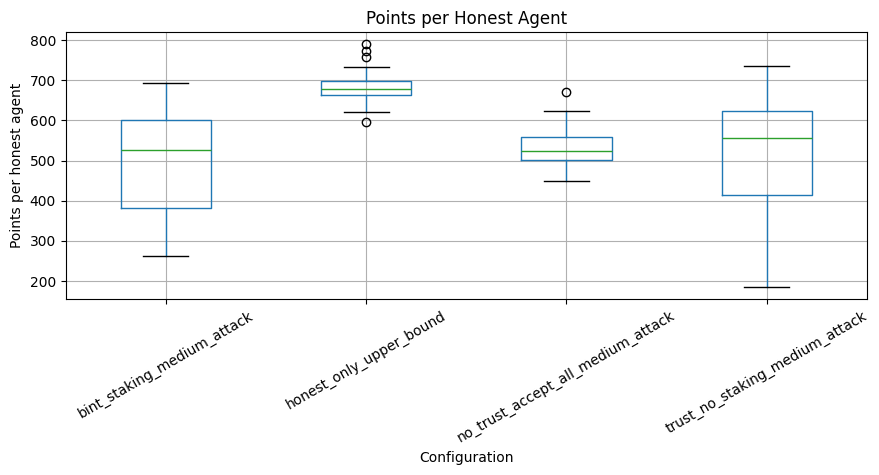

In [27]:
# -------------------------------------------------------------------
# Figure: points per honest agent
# -------------------------------------------------------------------

plot_final_metric(
    points_final_df,
    "points_per_honest_agent",
    title="Points per Honest Agent",
    ylabel="Points per honest agent",
    save_as="points_per_honest_agent.png",
)

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/points_per_malicious_agent.png


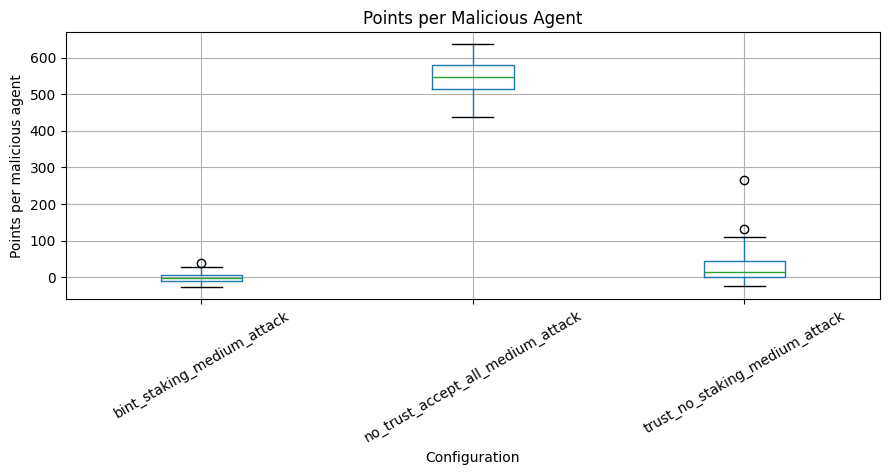

In [28]:
# -------------------------------------------------------------------
# Figure: points per malicious agent
# -------------------------------------------------------------------

malicious_points_plot_df = points_final_df[
    points_final_df["malicious_agents"] > 0
].copy()

plot_final_metric(
    malicious_points_plot_df,
    "points_per_malicious_agent",
    title="Points per Malicious Agent",
    ylabel="Points per malicious agent",
    save_as="points_per_malicious_agent.png",
)

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/points_gap_honest_minus_malicious.png


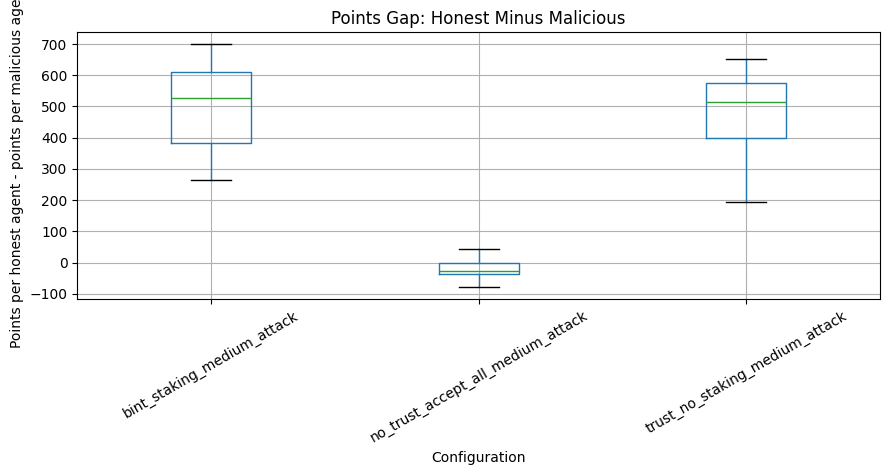

In [29]:
# -------------------------------------------------------------------
# Figure: honest-minus-malicious points gap
# -------------------------------------------------------------------

points_gap_plot_df = points_final_df[
    points_final_df["malicious_agents"] > 0
].copy()

plot_final_metric(
    points_gap_plot_df,
    "points_gap_honest_minus_malicious",
    title="Points Gap: Honest Minus Malicious",
    ylabel="Points per honest agent - points per malicious agent",
    save_as="points_gap_honest_minus_malicious.png",
)

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/points_per_delivery.png


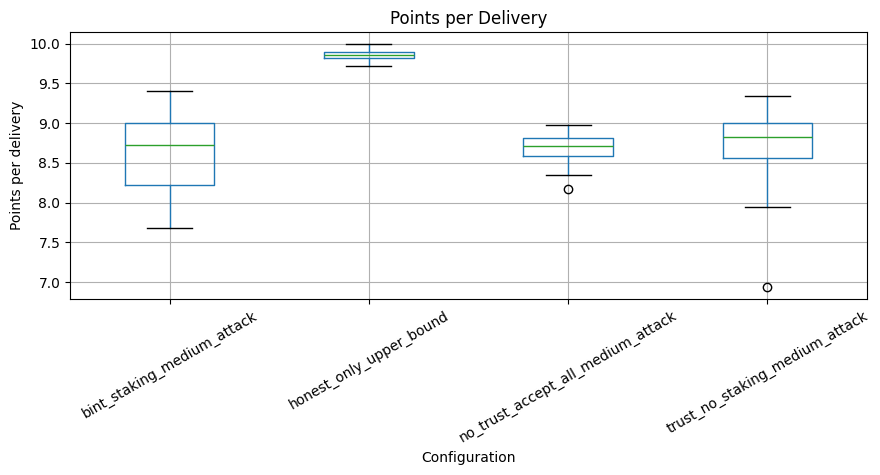

In [30]:
# -------------------------------------------------------------------
# Figure: points per delivery
# -------------------------------------------------------------------

plot_final_metric(
    points_final_df,
    "points_per_delivery",
    title="Points per Delivery",
    ylabel="Points per delivery",
    save_as="points_per_delivery.png",
)

In [31]:
# -------------------------------------------------------------------
# Efficiency table: honest vs malicious points per delivery
# -------------------------------------------------------------------

efficiency_cols = [
    "points_per_delivery",
    "honest_points_per_delivery",
    "malicious_points_per_delivery",
]

efficiency_table = (
    points_final_df
    .groupby("config")[
        [col for col in efficiency_cols if col in points_final_df.columns]
    ]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

display(efficiency_table)

points_per_delivery                      honest_points_per_delivery                      malicious_points_per_delivery                     
                                                 mean    std    min    max                       mean    std    min    max                          mean    std    min    max
config                                                                                                                                                                       
bint_staking_medium_attack                      8.624  0.505  7.685  9.407                      8.927  0.461  8.007  9.561                        -1.321  3.603 -9.286  4.318
honest_only_upper_bound                         9.855  0.062  9.718  9.989                      9.855  0.062  9.718  9.989                           NaN    NaN    NaN    NaN
no_trust_accept_all_medium_attack               8.685  0.177  8.170  8.971                      8.638  0.192  8.128  9.069                         8.789  0.262  8.240  9.295
trust_no_staking_medium_attack                  8.684  0.496  6.940  9.345                      9.112  0.467  7.406  9.644                         1.798  3.243 -5.190  7.268

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/honest_points_over_time.png


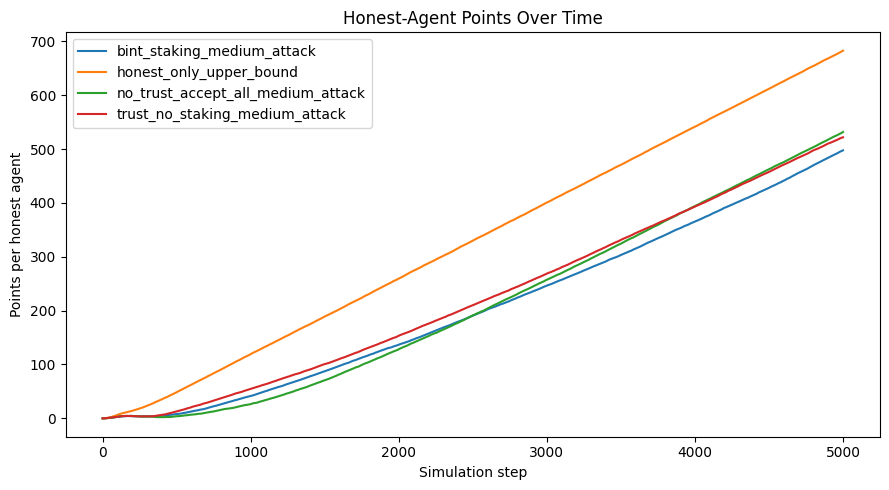

In [32]:
# -------------------------------------------------------------------
# Figure: honest points over time
# -------------------------------------------------------------------

plot_time_metric(
    points_trajectory_df,
    "points_per_honest_agent",
    title="Honest-Agent Points Over Time",
    ylabel="Points per honest agent",
    save_as="honest_points_over_time.png",
)

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/malicious_points_over_time.png


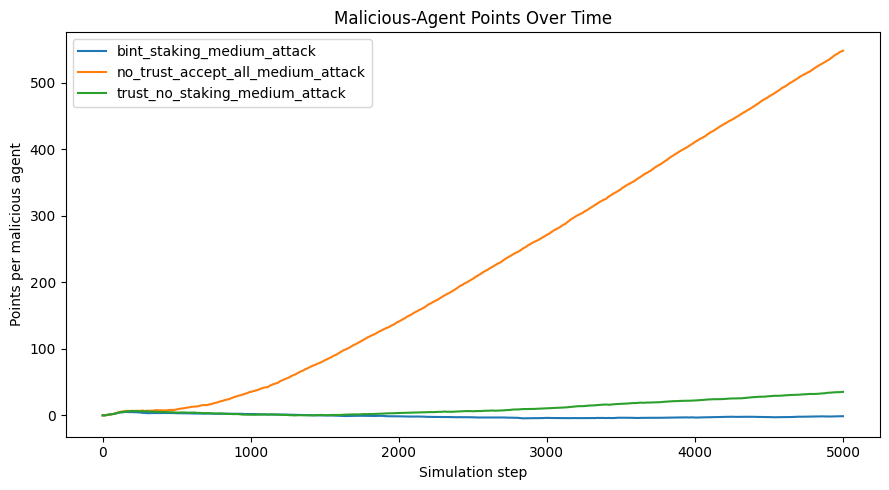

In [33]:
# -------------------------------------------------------------------
# Figure: malicious points over time
# -------------------------------------------------------------------

malicious_points_trajectory_df = points_trajectory_df[
    points_trajectory_df["malicious_agents"] > 0
].copy()

plot_time_metric(
    malicious_points_trajectory_df,
    "points_per_malicious_agent",
    title="Malicious-Agent Points Over Time",
    ylabel="Points per malicious agent",
    save_as="malicious_points_over_time.png",
)

In [34]:
# -------------------------------------------------------------------
# Quick comparison against BINT
# -------------------------------------------------------------------

REFERENCE_CONFIG = "bint_staking_medium_attack"

key_metrics = [
    "points_per_honest_agent",
    "points_per_malicious_agent",
    "points_gap_honest_minus_malicious",
    "points_per_delivery",
    "failure_rate",
    "accepted_malicious_provider_rate",
]

mean_metrics = (
    points_final_df
    .groupby("config")[
        [metric for metric in key_metrics if metric in points_final_df.columns]
    ]
    .mean()
)

if REFERENCE_CONFIG in mean_metrics.index:
    comparison_vs_bint = (
        mean_metrics
        .subtract(mean_metrics.loc[REFERENCE_CONFIG], axis="columns")
        .round(3)
    )

    display(mean_metrics.round(3))
    display(comparison_vs_bint)
else:
    display(mean_metrics.round(3))

,points_per_honest_agent,points_per_malicious_agent,points_gap_honest_minus_malicious,points_per_delivery,failure_rate,accepted_malicious_provider_rate
config,,,,,,
bint_staking_medium_attack,497.626,-1.294,498.921,8.624,0.100,0.110
honest_only_upper_bound,682.636,NaN,NaN,9.855,0.000,0.000
no_trust_accept_all_medium_attack,531.690,547.767,-16.077,8.685,0.349,0.490
trust_no_staking_medium_attack,521.913,35.271,486.643,8.684,0.163,0.172


,points_per_honest_agent,points_per_malicious_agent,points_gap_honest_minus_malicious,points_per_delivery,failure_rate,accepted_malicious_provider_rate
config,,,,,,
bint_staking_medium_attack,0.000,0.000,0.000,0.000,0.000,0.000
honest_only_upper_bound,185.010,NaN,NaN,1.231,-0.100,-0.110
no_trust_accept_all_medium_attack,34.064,549.061,-514.997,0.061,0.250,0.380
trust_no_staking_medium_attack,24.287,36.565,-12.278,0.059,0.064,0.062


In [35]:
# -------------------------------------------------------------------
# Clean scenario-inapplicable metrics
# -------------------------------------------------------------------

def clean_inapplicable_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    no_malicious = df["malicious_agents"] == 0

    cols_to_blank = [
        "points_per_malicious_agent",
        "malicious_points_per_delivery",
        "points_gap_honest_minus_malicious",
        "avg_trust_malicious",
        "trust_gap_honest_minus_malicious",
        "accepted_malicious_provider_rate",
        "malicious_burns_per_malicious_agent",
        "malicious_burn_share",
    ]

    for col in cols_to_blank:
        if col in df.columns:
            df.loc[no_malicious, col] = np.nan

    return df


points_final_clean_df = clean_inapplicable_metrics(points_final_df)
points_trajectory_clean_df = clean_inapplicable_metrics(points_trajectory_df)

In [36]:
SCENARIO_LABELS = {
    "honest_only_upper_bound": "Honest-only",
    "no_trust_accept_all_medium_attack": "No trust\naccept-all",
    "trust_no_staking_medium_attack": "Trust\nno staking",
    "bint_staking_medium_attack": "BINT\nstaking",
}

SCENARIO_ORDER = [
    "honest_only_upper_bound",
    "no_trust_accept_all_medium_attack",
    "trust_no_staking_medium_attack",
    "bint_staking_medium_attack",
]


def ordered_labeled_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["scenario_label"] = df["config"].map(SCENARIO_LABELS).fillna(df["config"])
    df["scenario_label"] = pd.Categorical(
        df["scenario_label"],
        categories=[SCENARIO_LABELS[c] for c in SCENARIO_ORDER if c in SCENARIO_LABELS],
        ordered=True,
    )
    return df.sort_values("scenario_label")

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/points_summary_2x2.png


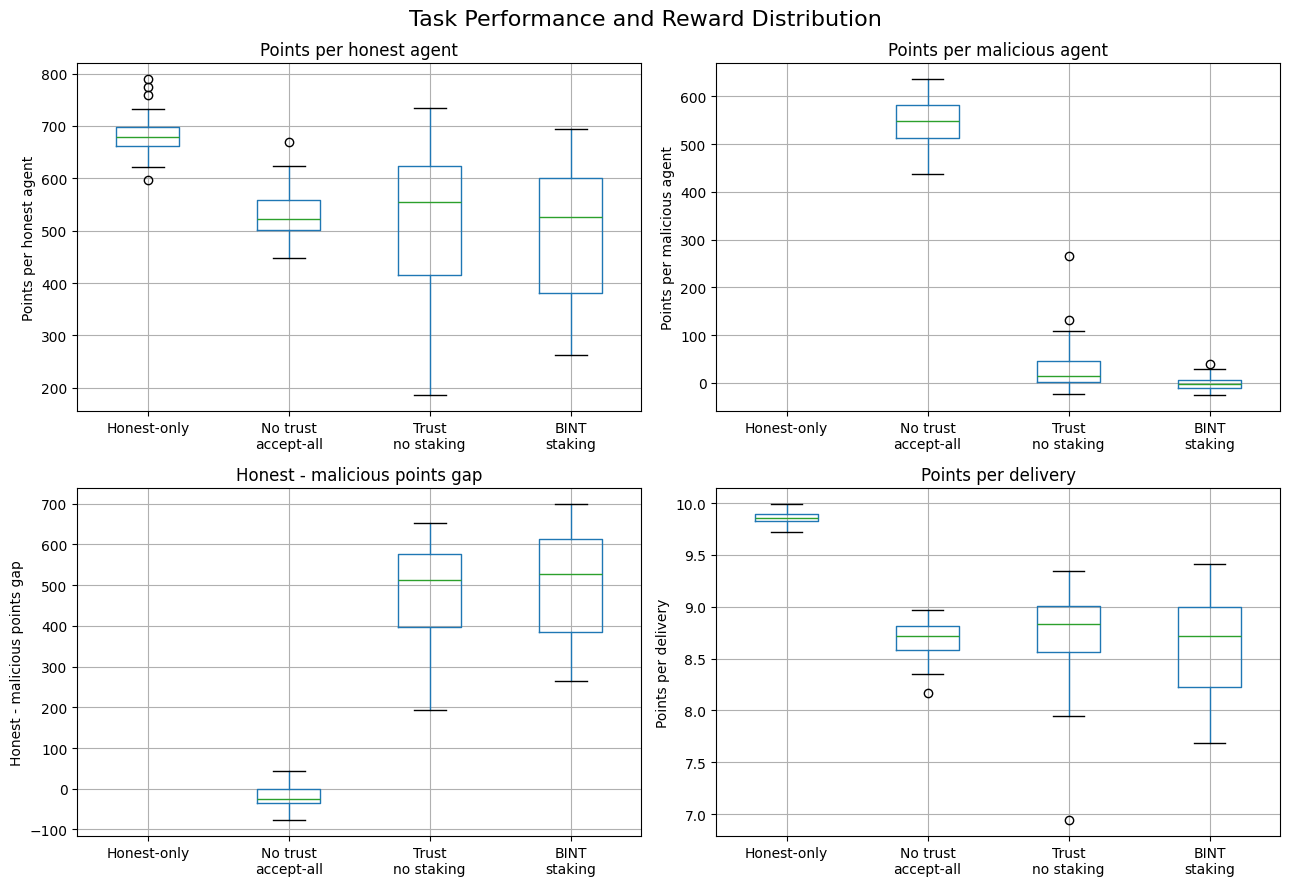

In [37]:
# -------------------------------------------------------------------
# Compact points summary figure
# -------------------------------------------------------------------

plot_df = ordered_labeled_df(points_final_clean_df)

metrics_to_plot = [
    ("points_per_honest_agent", "Points per honest agent"),
    ("points_per_malicious_agent", "Points per malicious agent"),
    ("points_gap_honest_minus_malicious", "Honest - malicious points gap"),
    ("points_per_delivery", "Points per delivery"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (metric, title) in zip(axes, metrics_to_plot):
    available = plot_df.dropna(subset=[metric])

    available.boxplot(
        column=metric,
        by="scenario_label",
        ax=ax,
        rot=0,
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(title)

fig.suptitle("Task Performance and Reward Distribution", fontsize=16)
fig.tight_layout()

save_current_figure("points_summary_2x2.png")
plt.show()

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/points_security_performance_tradeoff.png


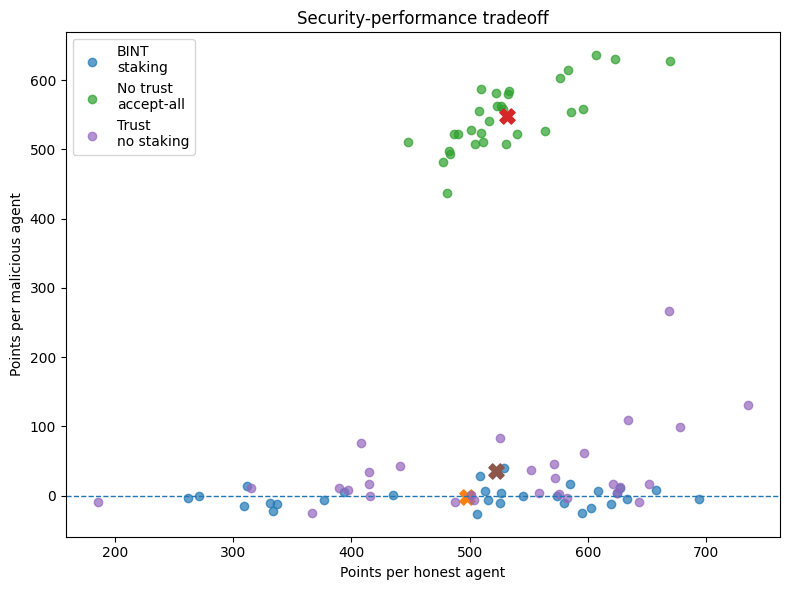

In [38]:
# -------------------------------------------------------------------
# Security-performance tradeoff:
# x = honest reward, y = malicious reward
# Ideal direction: high honest points, low malicious points.
# -------------------------------------------------------------------

tradeoff_df = points_final_clean_df[
    points_final_clean_df["malicious_agents"] > 0
].copy()

fig, ax = plt.subplots(figsize=(8, 6))

for config_name, config_df in tradeoff_df.groupby("config"):
    label = SCENARIO_LABELS.get(config_name, config_name)

    ax.scatter(
        config_df["points_per_honest_agent"],
        config_df["points_per_malicious_agent"],
        alpha=0.7,
        label=label,
    )

    ax.scatter(
        config_df["points_per_honest_agent"].mean(),
        config_df["points_per_malicious_agent"].mean(),
        marker="X",
        s=120,
    )

ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Security-performance tradeoff")
ax.set_xlabel("Points per honest agent")
ax.set_ylabel("Points per malicious agent")
ax.legend()
fig.tight_layout()

save_current_figure("points_security_performance_tradeoff.png")
plt.show()

In [39]:
# -------------------------------------------------------------------
# Thesis-style points table
# -------------------------------------------------------------------

thesis_points_cols = [
    "points_per_honest_agent",
    "points_per_malicious_agent",
    "points_gap_honest_minus_malicious",
    "points_per_delivery",
    "failure_rate",
    "accepted_malicious_provider_rate",
]

thesis_points_table = (
    points_final_clean_df
    .groupby("config")[
        [c for c in thesis_points_cols if c in points_final_clean_df.columns]
    ]
    .mean()
    .reindex(SCENARIO_ORDER)
    .rename(index=SCENARIO_LABELS)
    .round(3)
)

display(thesis_points_table)

,points_per_honest_agent,points_per_malicious_agent,points_gap_honest_minus_malicious,points_per_delivery,failure_rate,accepted_malicious_provider_rate
config,,,,,,
Honest-only,682.636,NaN,NaN,9.855,0.000,NaN
No trust\naccept-all,531.690,547.767,-16.077,8.685,0.349,0.490
Trust\nno staking,521.913,35.271,486.643,8.684,0.163,0.172
BINT\nstaking,497.626,-1.294,498.921,8.624,0.100,0.110


In [41]:
plt.close("all")

del malicious_points_plot_df
del points_gap_plot_df
del malicious_points_trajectory_df

import gc
gc.collect()

17068

Task performance and reward distribution

The first part of the evaluation examines whether BINT preserves useful task performance while limiting the benefit gained by malicious agents. In this environment, task performance is measured using the agents’ accumulated points. This is more informative than only counting completed deliveries, because the points calculation also reflects delivery quality: delayed or inefficient deliveries receive lower rewards. Therefore, the analysis considers both productivity metrics, such as points per agent, and efficiency metrics, such as points per delivery.

Four scenarios are compared. The honest-only scenario acts as an upper-bound reference in which all delivery agents are honest and no malicious map-sharing or review behaviour occurs. The no-trust accept-all scenario approximates a system in which agents do not meaningfully filter interaction partners using trust. The trust-without-staking scenario uses trust scores and reviewer filtering but disables staking. Finally, the BINT scenario uses the full model, including trust evaluation, reviewer filtering, and bidirectional staking. All attack scenarios use the medium attack setting, where malicious agents have a 0.50 probability of providing false map information, false negative reviews, and false positive reviews.

As expected, the honest-only scenario achieves the strongest task performance. Honest agents reach an average of 682.636 points per agent and 9.855 points per delivery. This provides a useful upper bound: in the absence of malicious behaviour, agents can complete deliveries efficiently and consistently. Under attack, all other scenarios experience some reduction in honest-agent performance. This is expected, because malicious map information and false reviews introduce uncertainty and wasted movement into the system.

The no-trust accept-all scenario produces relatively high honest-agent rewards, with honest agents achieving 531.690 points per agent. However, this result is misleading if considered alone. In the same scenario, malicious agents achieve 547.767 points per agent, which is slightly higher than the honest agents. The honest-minus-malicious points gap is therefore negative at -16.077. This indicates that unrestricted interaction allows malicious agents to benefit heavily from the system rather than being penalized for harmful behaviour. The no-trust scenario also has the highest failure rate, 0.349, and the highest accepted malicious provider rate, 0.490. Thus, although the no-trust baseline appears productive, it is not robust: malicious agents are able to participate successfully and gain high rewards.

Adding trust without staking improves this situation substantially. In the trust-without-staking scenario, honest agents achieve 521.913 points per agent, while malicious agents fall to 35.271 points per agent. The honest-minus-malicious points gap becomes strongly positive at 486.643. This shows that trust evaluation alone already helps distinguish honest and malicious agents and reduces malicious reward. However, the failure rate remains 0.163 and the accepted malicious provider rate remains 0.172, both higher than in the full BINT setting. Malicious agents are therefore limited, but not fully contained.

The full BINT scenario produces the strongest reward separation. Honest agents achieve 497.626 points per agent, while malicious agents average -1.294 points per agent. The honest-minus-malicious points gap is 498.921, slightly higher than in the trust-without-staking case. This means that BINT does not maximize honest-agent reward, but it does almost completely remove malicious reward. Compared with trust alone, BINT reduces malicious points from 35.271 to -1.294, reduces the failure rate from 0.163 to 0.100, and reduces the accepted malicious provider rate from 0.172 to 0.110. This suggests that staking adds an important deterrent effect beyond trust scoring alone.

The efficiency metrics show a similar tradeoff. The honest-only scenario has the highest points per delivery, 9.855, because there is no adversarial interference. Under attack, the three medium-attack scenarios have similar overall points per delivery: 8.624 for BINT, 8.685 for no-trust accept-all, and 8.684 for trust without staking. However, the group-specific values show an important difference. In the no-trust scenario, malicious agents achieve 8.789 points per delivery, meaning their deliveries remain highly rewarding. In the trust-without-staking scenario, malicious points per delivery fall to 1.798. In the full BINT scenario, malicious points per delivery become negative, at -1.321. BINT therefore does not merely reduce malicious activity; it changes the reward structure so that malicious agents no longer benefit from participation in the same way.

Overall, these results show that BINT introduces a security-performance tradeoff. The full BINT model gives honest agents fewer points than the no-trust and trust-without-staking scenarios, but the loss is moderate compared with the reduction in malicious benefit and failure rate. The no-trust system allows high activity but also allows malicious agents to earn high rewards. Trust without staking improves reward separation, but malicious agents still retain positive reward and the failure rate remains higher. BINT with staking provides the clearest separation between honest and malicious agents, keeps malicious rewards near or below zero, and substantially reduces harmful accepted interactions. Therefore, the points analysis supports the claim that BINT preserves useful honest-agent performance while limiting the ability of malicious agents to profit from the system.

Suggested figure captions

Figure X. Honest-agent points over time.
This figure shows the average points accumulated by honest agents in each scenario. The honest-only scenario provides an upper-bound reference. Under medium attack, BINT achieves lower honest-agent reward than the unrestricted baselines, but still maintains steady growth in honest-agent points.

Figure X. Malicious-agent points over time.
This figure shows the average points accumulated by malicious agents. In the no-trust accept-all baseline, malicious-agent points increase rapidly throughout the simulation. Trust without staking reduces this growth, while BINT with staking keeps malicious-agent points close to zero or below zero.

Figure X. Points per honest and malicious agent.
This figure compares the final reward distribution across scenarios. The no-trust baseline allows malicious agents to earn high rewards, while trust-based filtering reduces malicious reward. BINT with staking produces the strongest reward separation, with honest agents retaining substantial reward and malicious agents receiving approximately zero or negative reward.

Figure X. Points per delivery.
This figure compares delivery efficiency across scenarios. The honest-only scenario achieves the highest efficiency. Under attack, the medium-attack scenarios have similar overall points per delivery, but group-specific results show that BINT strongly reduces the reward efficiency of malicious agents.

In [ ]:
# -------------------------------------------------------------------
# Reuse the points evaluation outputs for aggregate trust analysis
# -------------------------------------------------------------------

if "points_trajectory_clean_df" in globals():
    trust_trajectory_df = points_trajectory_clean_df.copy()
else:
    trust_trajectory_df = points_trajectory_df.copy()

if "points_final_clean_df" in globals():
    trust_final_df = points_final_clean_df.copy()
else:
    trust_final_df = points_final_df.copy()


# Make sure scenario labels exist.
SCENARIO_LABELS = {
    "honest_only_upper_bound": "Honest-only",
    "no_trust_accept_all_medium_attack": "No trust\naccept-all",
    "trust_no_staking_medium_attack": "Trust\nno staking",
    "bint_staking_medium_attack": "BINT\nstaking",
}

SCENARIO_ORDER = [
    "honest_only_upper_bound",
    "no_trust_accept_all_medium_attack",
    "trust_no_staking_medium_attack",
    "bint_staking_medium_attack",
]


trust_trajectory_df = add_scenario_labels(trust_trajectory_df)
trust_final_df = add_scenario_labels(trust_final_df)

In [43]:
# -------------------------------------------------------------------
# Trust-focused summary table
# -------------------------------------------------------------------

TRUST_SUMMARY_METRICS = [
    "avg_trust_honest",
    "avg_trust_malicious",
    "trust_gap_honest_minus_malicious",
    "accepted_malicious_provider_rate",
    "failure_rate",
    "points_gap_honest_minus_malicious",
]

trust_summary_table = (
    trust_final_df
    .groupby("config")[
        [metric for metric in TRUST_SUMMARY_METRICS if metric in trust_final_df.columns]
    ]
    .agg(["mean", "std", "min", "max"])
    .round(3)
    .reindex(SCENARIO_ORDER)
)

display(trust_summary_table)

avg_trust_honest                      avg_trust_malicious                      trust_gap_honest_minus_malicious                       \
                                              mean    std    min    max                mean    std    min    max                             mean    std    min    max   
config                                                                                                                                                                   
honest_only_upper_bound                      0.957  0.001  0.953  0.960                 NaN    NaN    NaN    NaN                              NaN    NaN    NaN    NaN   
no_trust_accept_all_medium_attack            0.803  0.020  0.762  0.840               0.231  0.040  0.139  0.337                            0.572  0.044  0.485  0.682   
trust_no_staking_medium_attack               0.914  0.019  0.864  0.941               0.267  0.032  0.208  0.325                            0.647  0.045  0.542  0.729   
bint_staking_medium_attack                   0.904  0.020  0.853  0.935               0.278  0.018  0.248  0.319                            0.626  0.024  0.555  0.659   

                                  accepted_malicious_provider_rate                      failure_rate                      points_gap_honest_minus_malicious                             
                                                              mean    std    min    max         mean    std    min    max                              mean      std      min      max  
config                                                                                                                                                                                  
honest_only_upper_bound                                        NaN    NaN    NaN    NaN        0.000  0.000  0.000  0.000                               NaN      NaN      NaN      NaN  
no_trust_accept_all_medium_attack                            0.490  0.020  0.456  0.545        0.349  0.019  0.312  0.391                           -16.077   33.033  -77.361   43.347  
trust_no_staking_medium_attack                               0.172  0.034  0.126  0.239        0.163  0.025  0.125  0.218                           486.643  112.452  194.442  652.484  
bint_staking_medium_attack                                   0.110  0.020  0.077  0.149        0.100  0.016  0.071  0.144                           498.921  127.053  265.325  698.624

In [44]:
# -------------------------------------------------------------------
# Compact trust table for interpretation
# -------------------------------------------------------------------

compact_trust_cols = [
    "avg_trust_honest",
    "avg_trust_malicious",
    "trust_gap_honest_minus_malicious",
    "accepted_malicious_provider_rate",
    "failure_rate",
]

compact_trust_table = (
    trust_final_df
    .groupby("config")[
        [col for col in compact_trust_cols if col in trust_final_df.columns]
    ]
    .mean()
    .reindex(SCENARIO_ORDER)
    .rename(index=SCENARIO_LABELS)
    .round(3)
)

display(compact_trust_table)

,avg_trust_honest,avg_trust_malicious,trust_gap_honest_minus_malicious,accepted_malicious_provider_rate,failure_rate
config,,,,,
Honest-only,0.957,NaN,NaN,NaN,0.000
No trust\naccept-all,0.803,0.231,0.572,0.490,0.349
Trust\nno staking,0.914,0.267,0.647,0.172,0.163
BINT\nstaking,0.904,0.278,0.626,0.110,0.100


Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/trust_honest_over_time.png


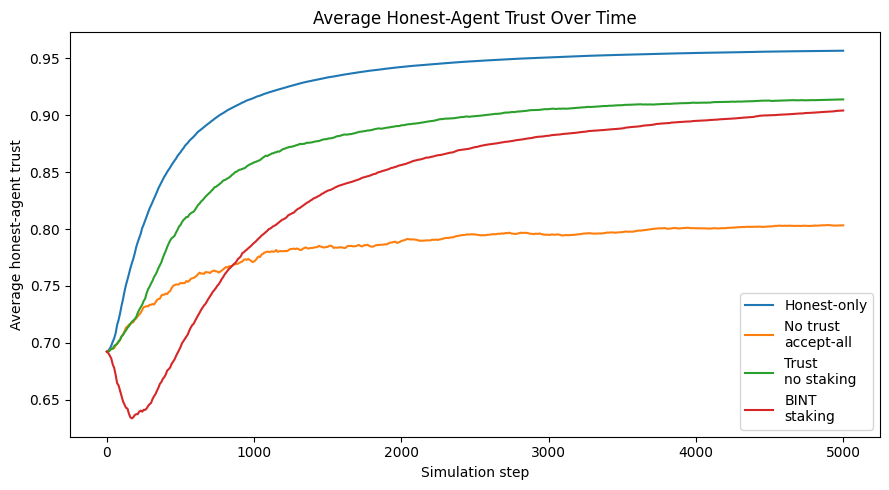

In [45]:
# -------------------------------------------------------------------
# Figure: average honest trust over time
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

plot_df = (
    trust_trajectory_df
    .groupby(["scenario_label", "sim_step"], as_index=False)["avg_trust_honest"]
    .mean()
    .sort_values(["scenario_label", "sim_step"])
)

for label, scenario_df in plot_df.groupby("scenario_label"):
    ax.plot(
        scenario_df["sim_step"],
        scenario_df["avg_trust_honest"],
        label=label,
    )

ax.set_title("Average Honest-Agent Trust Over Time")
ax.set_xlabel("Simulation step")
ax.set_ylabel("Average honest-agent trust")
ax.legend()
fig.tight_layout()

save_current_figure("trust_honest_over_time.png")
plt.show()

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/trust_malicious_over_time.png


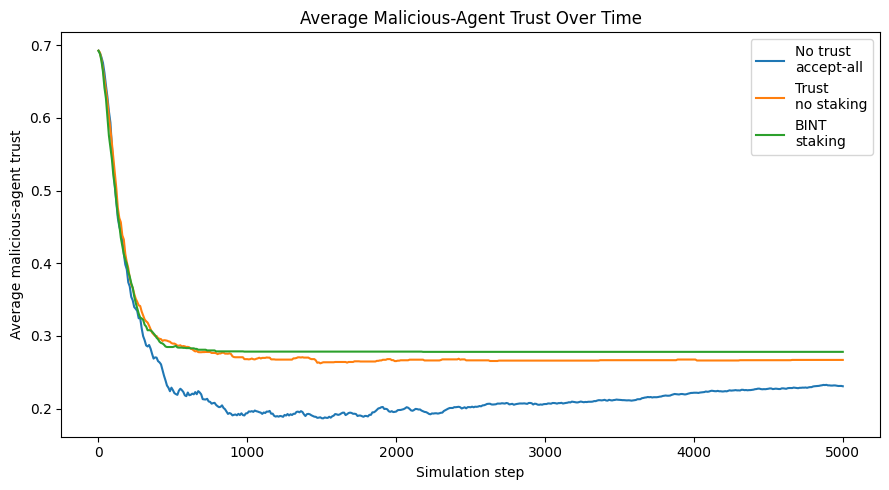

In [46]:
# -------------------------------------------------------------------
# Figure: average malicious trust over time
# -------------------------------------------------------------------

malicious_trust_trajectory_df = trust_trajectory_df[
    trust_trajectory_df["malicious_agents"] > 0
].copy()

fig, ax = plt.subplots(figsize=(9, 5))

plot_df = (
    malicious_trust_trajectory_df
    .groupby(["scenario_label", "sim_step"], as_index=False)["avg_trust_malicious"]
    .mean()
    .sort_values(["scenario_label", "sim_step"])
)

for label, scenario_df in plot_df.groupby("scenario_label"):
    ax.plot(
        scenario_df["sim_step"],
        scenario_df["avg_trust_malicious"],
        label=label,
    )

ax.set_title("Average Malicious-Agent Trust Over Time")
ax.set_xlabel("Simulation step")
ax.set_ylabel("Average malicious-agent trust")
ax.legend()
fig.tight_layout()

save_current_figure("trust_malicious_over_time.png")
plt.show()

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/trust_gap_over_time.png


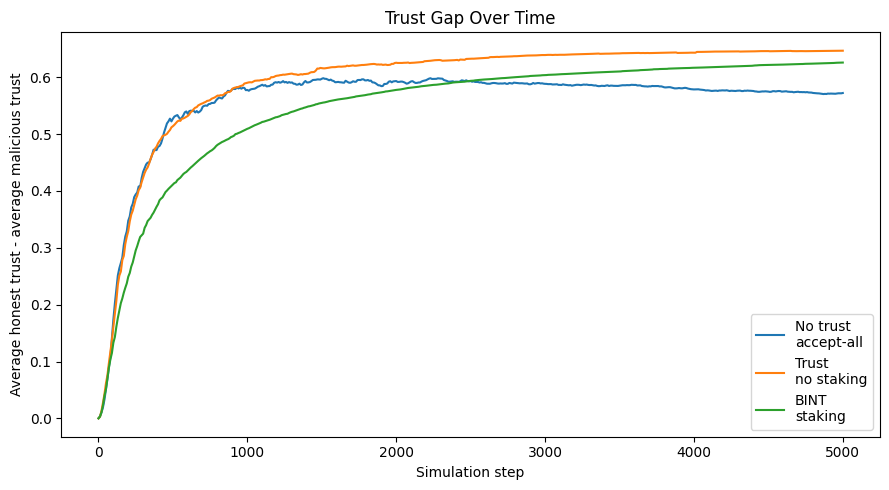

In [47]:
# -------------------------------------------------------------------
# Figure: trust gap over time
# -------------------------------------------------------------------

trust_gap_trajectory_df = trust_trajectory_df[
    trust_trajectory_df["malicious_agents"] > 0
].copy()

fig, ax = plt.subplots(figsize=(9, 5))

plot_df = (
    trust_gap_trajectory_df
    .groupby(["scenario_label", "sim_step"], as_index=False)["trust_gap_honest_minus_malicious"]
    .mean()
    .sort_values(["scenario_label", "sim_step"])
)

for label, scenario_df in plot_df.groupby("scenario_label"):
    ax.plot(
        scenario_df["sim_step"],
        scenario_df["trust_gap_honest_minus_malicious"],
        label=label,
    )

ax.set_title("Trust Gap Over Time")
ax.set_xlabel("Simulation step")
ax.set_ylabel("Average honest trust - average malicious trust")
ax.legend()
fig.tight_layout()

save_current_figure("trust_gap_over_time.png")
plt.show()

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/final_trust_gap.png


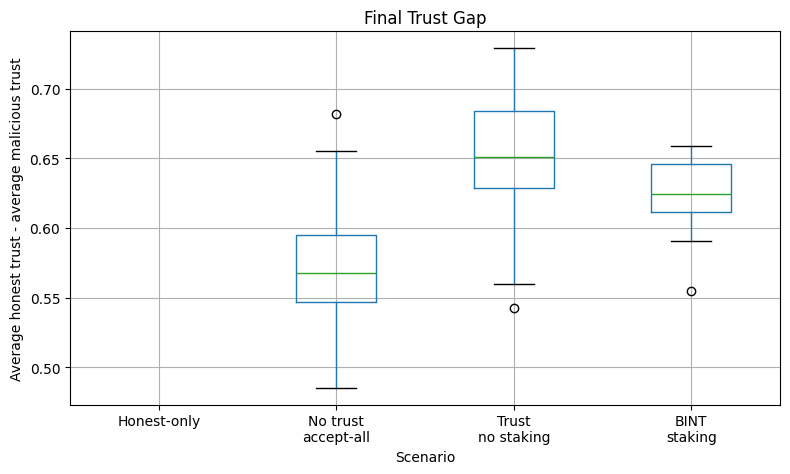

In [48]:
# -------------------------------------------------------------------
# Figure: final trust gap
# -------------------------------------------------------------------

trust_gap_final_df = trust_final_df[
    trust_final_df["malicious_agents"] > 0
].copy()

fig, ax = plt.subplots(figsize=(8, 5))

trust_gap_final_df.boxplot(
    column="trust_gap_honest_minus_malicious",
    by="scenario_label",
    ax=ax,
    rot=0,
)

ax.set_title("Final Trust Gap")
ax.set_xlabel("Scenario")
ax.set_ylabel("Average honest trust - average malicious trust")
fig.suptitle("")
fig.tight_layout()

save_current_figure("final_trust_gap.png")
plt.show()

In [66]:
# -------------------------------------------------------------------
# Final per-agent trust/reliability snapshot helpers
# Corrected version: provider reliability uses model.outcomes, not interaction.status.
# -------------------------------------------------------------------

def collect_final_agent_snapshot(
    model: BintWorldModel,
    *,
    config_name: str,
    seed: int,
) -> pd.DataFrame:
    kinds = agent_type_map(model)

    provider_success = Counter()
    provider_failure = Counter()
    provider_disputed = Counter()
    provider_interactions = Counter()

    for interaction_id, interaction in model.interactions.items():
        provider_id = interaction.trustee_id
        outcome = model.outcomes.get(interaction_id)

        if outcome is None:
            continue

        if outcome.status in {"success", "failure", "disputed"}:
            provider_interactions[provider_id] += 1

            if outcome.status == "success":
                provider_success[provider_id] += 1
            elif outcome.status == "failure":
                provider_failure[provider_id] += 1
            elif outcome.status == "disputed":
                provider_disputed[provider_id] += 1

    owner_ledger = Counter()

    for tnft in model.tnft_ledger:
        owner = tnft.get("owner")
        kind = "active" if tnft.get("status") else "burned"
        owner_ledger[(owner, kind)] += 1

        if tnft.get("status") and tnft.get("staked_for") is not None:
            owner_ledger[(owner, "staked")] += 1

    rows = []

    for agent in model.cached_delivery_agents:
        agent_id = agent.unique_id
        agent_kind_value = kinds.get(agent_id, "unknown")

        successes = provider_success[agent_id]
        failures = provider_failure[agent_id]
        disputed = provider_disputed[agent_id]
        provided = provider_interactions[agent_id]

        reviewer_summary = model.get_reviewer_summary(agent_id)
        total_reviews = int(reviewer_summary["total_reviews"])
        negative_reviews = int(reviewer_summary["negative_reviews"])

        rows.append(
            {
                "config": config_name,
                "seed": seed,
                "agent_id": agent_id,
                "agent_type": agent_kind_value,

                "final_trust_score": safe_trust_score(model, agent),

                "points": agent.points,
                "deliveries": agent.delivery_count,

                "provided_interactions": provided,
                "provider_successes": successes,
                "provider_failures": failures,
                "provider_disputed": disputed,
                "provider_reliability": successes / provided if provided else np.nan,
                "provider_failure_rate": failures / provided if provided else np.nan,

                "active_tnfts_owned": owner_ledger[(agent_id, "active")],
                "burned_tnfts_owned": owner_ledger[(agent_id, "burned")],
                "staked_tnfts_owned": owner_ledger[(agent_id, "staked")],

                "total_reviews_left": total_reviews,
                "negative_reviews_left": negative_reviews,
                "negative_review_rate": negative_reviews / total_reviews if total_reviews else np.nan,
            }
        )

    return pd.DataFrame(rows)


def run_agent_snapshot_one(
    config: dict[str, Any],
    *,
    config_name: str,
    seed: int,
) -> pd.DataFrame:
    model = make_model(config, seed)

    for _step in range(1, int(config["max_steps"]) + 1):
        model.step()

    return collect_final_agent_snapshot(
        model,
        config_name=config_name,
        seed=seed,
    )

In [67]:
# -------------------------------------------------------------------
# Parallel runner for final per-agent snapshots
# -------------------------------------------------------------------

def _agent_snapshot_worker(args):
    config_name, config, seed = args
    return run_agent_snapshot_one(
        config,
        config_name=config_name,
        seed=seed,
    )


def run_agent_snapshots_parallel(
    configs: list[tuple[str, dict[str, Any]]],
    seeds: list[int],
    *,
    max_workers: int = 4,
) -> pd.DataFrame:
    tasks = [
        (config_name, config, seed)
        for config_name, config in configs
        for seed in seeds
    ]

    ctx = mp.get_context("fork")

    parts = []
    start_time = time.time()

    with ProcessPoolExecutor(max_workers=max_workers, mp_context=ctx) as executor:
        futures = [executor.submit(_agent_snapshot_worker, task) for task in tasks]

        completed = 0
        total = len(futures)

        for future in as_completed(futures):
            parts.append(future.result())
            completed += 1

            if completed % 5 == 0 or completed == total:
                print(f"Completed {completed}/{total} final-agent snapshot runs")

    agent_df = pd.concat(parts, ignore_index=True)

    elapsed = time.time() - start_time
    print(f"Finished {len(tasks)} snapshot runs in {elapsed:.1f} seconds.")

    return agent_df

In [68]:
# -------------------------------------------------------------------
# Run final-agent trust snapshot
# -------------------------------------------------------------------

TRUST_AGENT_RUN_NAME = "trust_final_agent_snapshots"

trust_agent_df = run_agent_snapshots_parallel(
    POINTS_SCENARIOS,
    POINTS_SEEDS,
    max_workers=POINTS_MAX_WORKERS,
)

trust_agent_df = add_scenario_labels(trust_agent_df)

display(trust_agent_df.head())
display(trust_agent_df.groupby(["config", "agent_type"]).size())

Completed 5/120 final-agent snapshot runs
Completed 10/120 final-agent snapshot runs
Completed 15/120 final-agent snapshot runs
Completed 20/120 final-agent snapshot runs
Completed 25/120 final-agent snapshot runs
Completed 30/120 final-agent snapshot runs
Completed 35/120 final-agent snapshot runs
Completed 40/120 final-agent snapshot runs
Completed 45/120 final-agent snapshot runs
Completed 50/120 final-agent snapshot runs
Completed 55/120 final-agent snapshot runs
Completed 60/120 final-agent snapshot runs
Completed 65/120 final-agent snapshot runs
Completed 70/120 final-agent snapshot runs
Completed 75/120 final-agent snapshot runs
Completed 80/120 final-agent snapshot runs
Completed 85/120 final-agent snapshot runs
Completed 90/120 final-agent snapshot runs
Completed 95/120 final-agent snapshot runs
Completed 100/120 final-agent snapshot runs
Completed 105/120 final-agent snapshot runs
Completed 110/120 final-agent snapshot runs
Completed 115/120 final-agent snapshot runs
Complete

,config,seed,agent_id,agent_type,final_trust_score,points,deliveries,provided_interactions,provider_successes,provider_failures,provider_disputed,provider_reliability,provider_failure_rate,active_tnfts_owned,burned_tnfts_owned,staked_tnfts_owned,total_reviews_left,negative_reviews_left,negative_review_rate,scenario_label
0,honest_only_upper_bound,101,1,honest,0.929825,620.0,64,11,11,0,0,1.0,0.0,16,0,0,21,0,0.0,Honest-only
396,honest_only_upper_bound,2020,17,honest,0.966942,700.0,73,27,27,0,0,1.0,0.0,32,0,0,19,0,0.0,Honest-only
397,honest_only_upper_bound,2020,18,honest,0.956989,637.5,69,20,20,0,0,1.0,0.0,25,0,0,18,0,0.0,Honest-only
398,honest_only_upper_bound,2020,19,honest,0.956989,720.0,72,20,20,0,0,1.0,0.0,25,0,0,15,0,0.0,Honest-only
399,honest_only_upper_bound,2020,20,honest,0.929825,789.0,81,11,11,0,0,1.0,0.0,16,0,0,21,0,0.0,Honest-only


config                             agent_type
bint_staking_medium_attack         honest        420
                                   malicious     180
honest_only_upper_bound            honest        600
no_trust_accept_all_medium_attack  honest        420
                                   malicious     180
trust_no_staking_medium_attack     honest        420
                                   malicious     180
dtype: int64

In [69]:
# -------------------------------------------------------------------
# Sanity check: provider interactions should no longer be all zero
# -------------------------------------------------------------------

display(
    trust_agent_df
    .groupby(["config", "agent_type"])["provided_interactions"]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

display(
    trust_agent_df[
        ["config", "seed", "agent_id", "agent_type", "final_trust_score", "provided_interactions", "provider_reliability"]
    ].head(20)
)

mean    std  min  max
config                            agent_type                         
bint_staking_medium_attack        honest      16.974  5.934    1   35
                                  malicious    4.722  1.621    2   10
honest_only_upper_bound           honest      20.825  4.909    9   41
no_trust_accept_all_medium_attack honest      21.207  5.313    7   38
                                  malicious   40.633  6.557   21   61
trust_no_staking_medium_attack    honest      18.200  6.276    1   37
                                  malicious    8.267  2.057    5   16

,config,seed,agent_id,agent_type,final_trust_score,provided_interactions,provider_reliability
0,honest_only_upper_bound,101,1,honest,0.929825,11,1.0
396,honest_only_upper_bound,2020,17,honest,0.966942,27,1.0
397,honest_only_upper_bound,2020,18,honest,0.956989,20,1.0
398,honest_only_upper_bound,2020,19,honest,0.956989,20,1.0
399,honest_only_upper_bound,2020,20,honest,0.929825,11,1.0
400,honest_only_upper_bound,2121,1,honest,0.966942,27,1.0
401,honest_only_upper_bound,2121,2,honest,0.958763,21,1.0
395,honest_only_upper_bound,2020,16,honest,0.950617,17,1.0
402,honest_only_upper_bound,2121,3,honest,0.968992,29,1.0
404,honest_only_upper_bound,2121,5,honest,0.948052,16,1.0


In [70]:
# -------------------------------------------------------------------
# Save final-agent trust snapshot
# -------------------------------------------------------------------

trust_agent_path = save_dataframe(
    trust_agent_df,
    DATA_DIR / TRUST_AGENT_RUN_NAME / TRUST_AGENT_RUN_NAME,
)

print(trust_agent_path)

/home/javid/Documents/int/bint/bint/evaluation_outputs/data/trust_final_agent_snapshots/trust_final_agent_snapshots.parquet


In [78]:
# -------------------------------------------------------------------
# Final trust distribution summary
# -------------------------------------------------------------------

agent_trust_summary = (
    trust_agent_df
    .groupby(["config", "agent_type"])[
        [
            "final_trust_score",
            "provider_reliability",
            "points",
            "deliveries",
            "active_tnfts_owned",
            "burned_tnfts_owned",
        ]
    ]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

display(agent_trust_summary)

final_trust_score                      provider_reliability                        points                            deliveries                  \
                                                          mean    std    min    max                 mean    std    min    max     mean      std      min      max       mean     std min max   
config                            agent_type                                                                                                                                                   
bint_staking_medium_attack        honest                 0.904  0.071  0.353  0.972                0.984  0.074  0.000  1.000  497.626  177.465  -40.000  776.071     55.186  16.595   3  81   
                                  malicious              0.278  0.055  0.138  0.529                0.128  0.133  0.000  0.500   -1.294   30.133  -60.000  155.200      4.228   3.994   0  23   
honest_only_upper_bound           honest                 0.957  0.009  0.918  0.977                1.000  0.000  1.000  1.000  682.636   62.118  500.000  879.000     69.265   5.940  53  89   
no_trust_accept_all_medium_attack honest                 0.803  0.092  0.438  0.966                0.850  0.079  0.600  1.000  531.690   83.919  266.010  767.000     61.481   6.615  45  81   
                                  malicious              0.231  0.117  0.045  0.548                0.346  0.073  0.121  0.556  547.767   81.521  329.075  759.250     62.294   6.774  44  79   
trust_no_staking_medium_attack    honest                 0.914  0.053  0.619  0.975                0.959  0.054  0.667  1.000  521.913  192.989  -36.500  840.000     56.781  17.990   2  85   
                                  malicious              0.267  0.071  0.160  0.640                0.192  0.114  0.000  0.500   35.271  105.890  -73.500  578.333     10.406  12.932   0  64   

                                             active_tnfts_owned                burned_tnfts_owned                 
                                                           mean    std min max               mean    std min max  
config                            agent_type                                                                      
bint_staking_medium_attack        honest                 20.026  6.241   1  38              1.771  1.059   0   5  
                                  malicious               0.206  0.504   0   3              5.556  0.785   4   9  
honest_only_upper_bound           honest                 25.825  4.909  14  46              0.000  0.000   0   0  
no_trust_accept_all_medium_attack honest                 19.793  4.828   8  37              3.207  1.858   0  10  
                                  malicious               3.139  2.451   0  10             15.828  2.780   9  24  
trust_no_staking_medium_attack    honest                 21.762  6.045   6  42              0.719  0.867   0   4  
                                  malicious               0.817  1.054   0   5              5.844  0.824   4   8

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/final_trust_distribution_clean.png


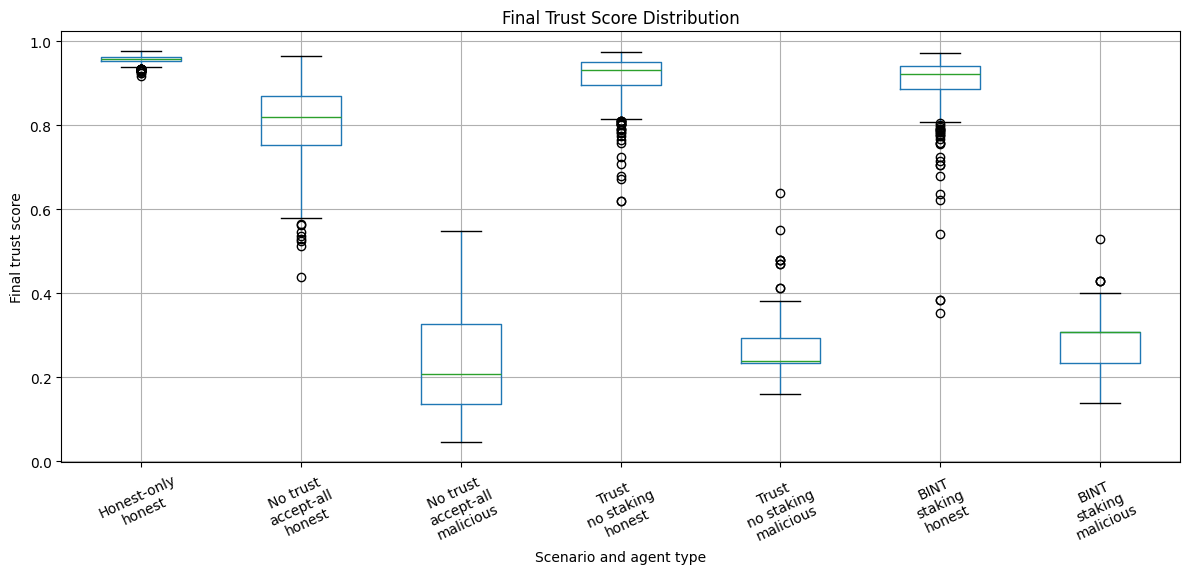

In [79]:
# -------------------------------------------------------------------
# Cleaner final trust distribution plot
# -------------------------------------------------------------------

trust_distribution_df = trust_agent_df.copy()

trust_distribution_df["scenario_agent_type"] = (
    trust_distribution_df["scenario_label"].astype(str)
    + "\n"
    + trust_distribution_df["agent_type"].astype(str)
)

order = [
    "Honest-only\nhonest",
    "No trust\naccept-all\nhonest",
    "No trust\naccept-all\nmalicious",
    "Trust\nno staking\nhonest",
    "Trust\nno staking\nmalicious",
    "BINT\nstaking\nhonest",
    "BINT\nstaking\nmalicious",
]

existing_order = [
    label for label in order
    if label in set(trust_distribution_df["scenario_agent_type"])
]

trust_distribution_df["scenario_agent_type"] = pd.Categorical(
    trust_distribution_df["scenario_agent_type"],
    categories=existing_order,
    ordered=True,
)

trust_distribution_df = trust_distribution_df.sort_values("scenario_agent_type")

fig, ax = plt.subplots(figsize=(12, 6))

trust_distribution_df.boxplot(
    column="final_trust_score",
    by="scenario_agent_type",
    ax=ax,
    rot=25,
)

ax.set_title("Final Trust Score Distribution")
ax.set_xlabel("Scenario and agent type")
ax.set_ylabel("Final trust score")
fig.suptitle("")
fig.tight_layout()

save_current_figure("final_trust_distribution_clean.png")
plt.show()

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/trust_score_vs_provider_reliability.png


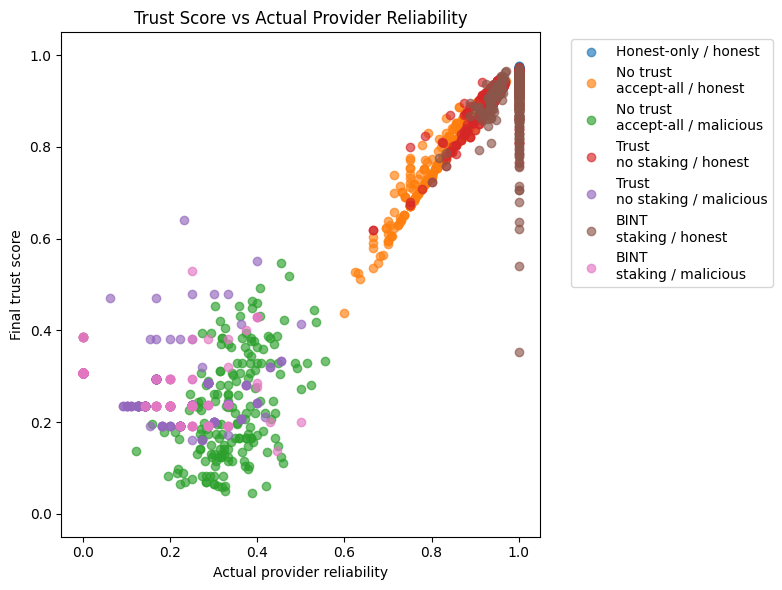

In [73]:
# -------------------------------------------------------------------
# Figure: trust score vs actual provider reliability
# -------------------------------------------------------------------

reliability_df = trust_agent_df[
    trust_agent_df["provided_interactions"] > 0
].copy()

fig, ax = plt.subplots(figsize=(8, 6))

for (scenario_label, agent_type), group_df in reliability_df.groupby(["scenario_label", "agent_type"]):
    ax.scatter(
        group_df["provider_reliability"],
        group_df["final_trust_score"],
        alpha=0.65,
        label=f"{scenario_label} / {agent_type}",
    )

ax.set_title("Trust Score vs Actual Provider Reliability")
ax.set_xlabel("Actual provider reliability")
ax.set_ylabel("Final trust score")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
fig.tight_layout()

save_current_figure("trust_score_vs_provider_reliability.png")
plt.show()

In [74]:
# -------------------------------------------------------------------
# Correlation between final trust score and actual provider reliability
# Safe version
# -------------------------------------------------------------------

if "reliability_df" not in globals():
    reliability_df = trust_agent_df[
        trust_agent_df["provided_interactions"] > 0
    ].copy()

correlation_rows = []

for config_name, config_df in reliability_df.groupby("config"):
    valid = config_df.dropna(
        subset=["provider_reliability", "final_trust_score"]
    )

    if len(valid) >= 3:
        corr = valid["provider_reliability"].corr(valid["final_trust_score"])
    else:
        corr = np.nan

    correlation_rows.append(
        {
            "config": config_name,
            "scenario": SCENARIO_LABELS.get(config_name, config_name),
            "n_agents_with_provider_interactions": len(valid),
            "trust_reliability_correlation": corr,
        }
    )

trust_reliability_correlation_df = pd.DataFrame(correlation_rows)

if trust_reliability_correlation_df.empty:
    print("No agents with provider interactions were found. Check provider_interactions calculation.")
else:
    display(
        trust_reliability_correlation_df
        .set_index("scenario")
        .round(3)
    )

/home/javid/Documents/int/bint/bint/.venv/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/javid/Documents/int/bint/bint/.venv/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,config,n_agents_with_provider_interactions,trust_reliability_correlation
scenario,,,
BINT\nstaking,bint_staking_medium_attack,600,0.955
Honest-only,honest_only_upper_bound,600,NaN
No trust\naccept-all,no_trust_accept_all_medium_attack,600,0.975
Trust\nno staking,trust_no_staking_medium_attack,600,0.973


In [75]:
# -------------------------------------------------------------------
# Compact final trust table
# -------------------------------------------------------------------

compact_agent_trust_table = (
    trust_agent_df
    .groupby(["config", "agent_type"])[
        [
            "final_trust_score",
            "provider_reliability",
            "points",
            "active_tnfts_owned",
            "burned_tnfts_owned",
        ]
    ]
    .mean()
    .round(3)
)

display(compact_agent_trust_table)

final_trust_score  provider_reliability   points  active_tnfts_owned  burned_tnfts_owned
config                            agent_type                                                                                          
bint_staking_medium_attack        honest                  0.904                 0.984  497.626              20.026               1.771
                                  malicious               0.278                 0.128   -1.294               0.206               5.556
honest_only_upper_bound           honest                  0.957                 1.000  682.636              25.825               0.000
no_trust_accept_all_medium_attack honest                  0.803                 0.850  531.690              19.793               3.207
                                  malicious               0.231                 0.346  547.767               3.139              15.828
trust_no_staking_medium_attack    honest                  0.914                 0.959  521.913              21.762               0.719
                                  malicious               0.267                 0.192   35.271               0.817               5.844

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/bint_trust_score_vs_provider_reliability.png


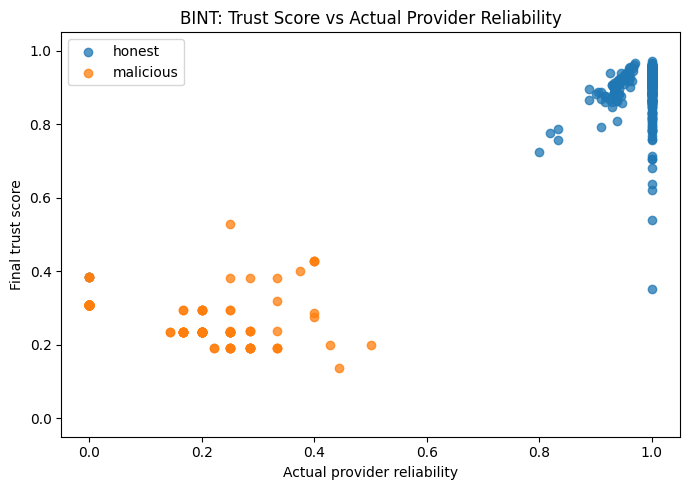

In [76]:
# -------------------------------------------------------------------
# BINT-only trust score vs actual provider reliability
# -------------------------------------------------------------------

bint_reliability_df = trust_agent_df[
    (trust_agent_df["config"] == "bint_staking_medium_attack")
    & (trust_agent_df["provided_interactions"] > 0)
].copy()

fig, ax = plt.subplots(figsize=(7, 5))

for agent_type, group_df in bint_reliability_df.groupby("agent_type"):
    ax.scatter(
        group_df["provider_reliability"],
        group_df["final_trust_score"],
        alpha=0.75,
        label=agent_type,
    )

ax.set_title("BINT: Trust Score vs Actual Provider Reliability")
ax.set_xlabel("Actual provider reliability")
ax.set_ylabel("Final trust score")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend()
fig.tight_layout()

save_current_figure("bint_trust_score_vs_provider_reliability.png")
plt.show()

In [80]:
# -------------------------------------------------------------------
# Compact trust interpretation table
# -------------------------------------------------------------------

trust_interpretation_table = (
    trust_agent_df
    .groupby(["config", "agent_type"])
    .agg(
        final_trust=("final_trust_score", "mean"),
        provider_reliability=("provider_reliability", "mean"),
        provided_interactions=("provided_interactions", "mean"),
        active_tnfts=("active_tnfts_owned", "mean"),
        burned_tnfts=("burned_tnfts_owned", "mean"),
        points=("points", "mean"),
    )
    .round(3)
)

display(trust_interpretation_table)

final_trust  provider_reliability  provided_interactions  active_tnfts  burned_tnfts   points
config                            agent_type                                                                                               
bint_staking_medium_attack        honest            0.904                 0.984                 16.974        20.026         1.771  497.626
                                  malicious         0.278                 0.128                  4.722         0.206         5.556   -1.294
honest_only_upper_bound           honest            0.957                 1.000                 20.825        25.825         0.000  682.636
no_trust_accept_all_medium_attack honest            0.803                 0.850                 21.207        19.793         3.207  531.690
                                  malicious         0.231                 0.346                 40.633         3.139        15.828  547.767
trust_no_staking_medium_attack    honest            0.914                 0.959                 18.200        21.762         0.719  521.913
                                  malicious         0.267                 0.192                  8.267         0.817         5.844   35.271

Trust-score evaluation

The second part of the evaluation examines whether the BINT trust score meaningfully distinguishes honest agents from malicious agents. This is important because BINT does not only aim to improve delivery performance; it aims to create a trust mechanism that allows agents to identify reliable and unreliable interaction partners. If the trust score does not correspond to actual behaviour, then later decisions based on that score would not be meaningful.

In the model, trust is calculated from token evidence. Active TNFTs act as positive evidence, while burned TNFTs act as negative evidence. Context-matching evidence is weighted more strongly than evidence from other service contexts, and the final trust score is calculated as a bounded ratio between weighted active and burned evidence with prior active and burned terms. This means that agents with more active evidence should receive higher trust scores, while agents with more burned evidence should receive lower trust scores.

The trust-score evaluation compares the same main scenarios used in the points analysis: an honest-only upper bound, a no-trust accept-all baseline, a trust-without-staking scenario, and the full BINT scenario with staking. The central question is whether honest agents end the simulation with higher trust scores than malicious agents, and whether these trust scores correspond to actual provider reliability.

The final trust-score distributions show clear separation between honest and malicious agents. In the full BINT scenario, honest agents reach an average final trust score of 0.904, while malicious agents reach an average final trust score of 0.278. This is a large gap, and the boxplot shows limited overlap between the two groups. Honest agents are concentrated near high trust values, while malicious agents remain concentrated near low trust values. This indicates that BINT successfully converts interaction outcomes into a useful reputation signal.

The honest-only scenario provides a useful upper-bound reference. Since all agents behave honestly, provider reliability is 1.000 for all agents, and their final trust scores are correspondingly high, with an average of 0.957. This confirms that the trust mechanism does not arbitrarily suppress trust in a non-adversarial environment. Instead, when agents repeatedly provide successful map information, active evidence accumulates and trust remains high.

The no-trust accept-all scenario is especially informative. In this scenario, the trust score still records behavioural evidence, but agents do not meaningfully use it to restrict interactions. Honest agents end with an average trust score of 0.803, while malicious agents end with an average trust score of 0.231. Therefore, even without trust-based filtering, the evidence recorded by the system still reflects the difference between honest and malicious behaviour. However, because the trust score is not used to prevent interactions, malicious agents continue to participate heavily and accumulate high rewards. This explains why the no-trust baseline can produce low malicious trust scores while still allowing malicious agents to benefit from the system.

The trust-without-staking scenario also shows strong trust separation. Honest agents reach an average final trust score of 0.914, while malicious agents reach 0.267. This is similar to the separation observed in the full BINT scenario. This result is important because it shows that staking is not primarily responsible for creating the trust-score separation. The trust mechanism itself is already able to distinguish reliable from unreliable agents. Staking instead changes the consequences of that trust information by requiring agents to put token evidence at risk during interactions.

This distinction is visible when trust scores are compared with the points results. Trust without staking identifies malicious agents and reduces their benefit compared with the no-trust baseline, but malicious agents still earn positive points on average. In contrast, BINT with staking keeps malicious-agent points near or below zero while maintaining a similar level of trust separation. This suggests that trust scoring and staking play complementary roles: trust scoring identifies unreliable agents, while staking makes unreliable behaviour more costly. In the points analysis, BINT reduced the failure rate to 0.100 and the accepted malicious provider rate to 0.110, compared with 0.163 and 0.172 for trust without staking, and 0.349 and 0.490 for the no-trust accept-all baseline.

The provider interaction counts support the same interpretation. In the no-trust accept-all scenario, malicious agents provide many interactions, averaging 40.633 provider interactions per malicious agent. This is almost twice the honest-agent provider average in the same scenario. In the trust-without-staking scenario, malicious agents provide only 8.267 interactions on average, and in the full BINT scenario this falls further to 4.722. This indicates that trust-based filtering and staking reduce the ability of malicious agents to remain active providers in the system.

The trust score also corresponds strongly to actual provider reliability. In the full BINT scenario, the correlation between final trust score and provider reliability is 0.955. The scatter plot confirms this relationship visually: honest agents cluster in the high-reliability, high-trust region, while malicious agents cluster in the low-reliability, low-trust region. This is one of the strongest pieces of evidence that the trust score is meaningful. It does not merely separate agents based on their type label; it tracks the actual reliability of agents as providers.

The same relationship also appears in the no-trust and trust-without-staking scenarios, where the trust-reliability correlations are 0.975 and 0.973 respectively. This shows that the trust-score formula consistently reflects actual interaction outcomes across scenarios. However, the consequences of that score differ depending on whether agents use trust filtering and staking. In the no-trust scenario, the score may correctly identify malicious agents after evidence accumulates, but this information is not used to prevent harmful interactions. In the full BINT scenario, the trust score is used together with staking, so low-trust agents face stronger restrictions and greater risk.

The final TNFT ownership patterns further support the trust-score interpretation. In the full BINT scenario, honest agents own an average of 20.026 active TNFTs and 1.771 burned TNFTs. Malicious agents own only 0.206 active TNFTs on average and 5.556 burned TNFTs. Since the trust score is based on the balance between active and burned evidence, this explains why honest agents receive high trust scores while malicious agents receive low trust scores. In the no-trust accept-all scenario, malicious agents accumulate more active TNFTs than in BINT, but they also accumulate many more burned TNFTs. This leads to low trust scores, but without interaction filtering, those low scores do not prevent malicious agents from profiting.

Overall, the trust-score results support three conclusions. First, the trust score clearly distinguishes honest and malicious agents. Second, the trust score corresponds closely to actual provider reliability. Third, trust scoring alone is not enough: it can identify malicious agents, but staking is needed to make malicious behaviour costly and reduce malicious benefit. Therefore, the trust-score analysis supports the internal validity of the BINT mechanism. The system does not merely produce better outcomes by chance; it generates a trust signal that reflects actual behavioural reliability and can be used to guide safer interactions.

Suggested figure captions

Figure X. Average honest-agent trust over time.
This figure shows how the average trust score of honest agents changes during the simulation. In the honest-only scenario, trust remains high because agents consistently provide reliable information. Under attack, honest-agent trust initially fluctuates but then recovers as successful interactions accumulate positive evidence.

Figure X. Average malicious-agent trust over time.
This figure shows how the average trust score of malicious agents changes during the simulation. Across the attack scenarios, malicious-agent trust falls quickly and remains low, indicating that harmful map-sharing behaviour is reflected in the TNFT evidence.

Figure X. Final trust score distribution.
This figure compares the final trust scores of honest and malicious agents in each scenario. Honest agents consistently receive higher trust scores than malicious agents. In the full BINT scenario, the separation is clear, with honest agents concentrated near high trust values and malicious agents concentrated near low trust values.

Figure X. Trust score versus actual provider reliability.
This figure compares each agent’s final trust score with its actual provider reliability. In the BINT scenario, agents with high provider reliability generally have high trust scores, while unreliable agents have low trust scores. This supports the claim that the trust score reflects actual behaviour.

Figure X. BINT trust score versus actual provider reliability.
This figure focuses only on the full BINT scenario. Honest agents cluster in the high-reliability, high-trust region, while malicious agents cluster in the low-reliability, low-trust region. This shows that BINT produces a meaningful trust signal under medium attack.

Shorter version for the report, if needed

The trust-score results show that BINT produces a meaningful distinction between honest and malicious agents. In the full BINT scenario, honest agents reach an average final trust score of 0.904, while malicious agents reach only 0.278. The final trust distribution shows clear separation between the two groups, and the BINT-specific trust-reliability plot shows that final trust score is strongly related to actual provider reliability. Agents with high provider reliability cluster near high trust scores, while unreliable malicious agents cluster near low trust scores.

The comparison with other scenarios clarifies the role of staking. Trust without staking also separates honest and malicious agents, with average trust scores of 0.914 and 0.267 respectively. This shows that the trust score itself is able to identify unreliable agents. However, the points analysis showed that malicious agents still earn positive rewards without staking. BINT therefore uses staking not primarily to create the trust signal, but to give that signal stronger consequences. Trust scoring identifies unreliable agents, while staking reduces their ability to profit from unreliable behaviour.

The no-trust accept-all baseline further supports this interpretation. Even in that scenario, malicious agents end with lower trust scores than honest agents, but because the score is not used to restrict interactions, malicious agents still participate heavily and earn high rewards. This shows that recording trust evidence is not enough by itself. The evidence must be used in decision-making, and BINT does this through trust filtering and staking. Overall, the trust-score results support the claim that BINT learns a behaviourally meaningful trust signal and uses it to support safer interaction decisions.

In [82]:
# -------------------------------------------------------------------
# Light cleanup before interaction/outcome analysis
# -------------------------------------------------------------------

import gc
import matplotlib.pyplot as plt

plt.close("all")

temporary_names = [
    "malicious_points_plot_df",
    "points_gap_plot_df",
    "malicious_points_trajectory_df",
    "malicious_trust_trajectory_df",
    "trust_gap_trajectory_df",
    "trust_gap_final_df",
    "trust_distribution_df",
    "reliability_df",
    "bint_reliability_df",
    "plot_df",
]

for name in temporary_names:
    if name in globals():
        del globals()[name]

gc.collect()

0

In [83]:
# -------------------------------------------------------------------
# Prepare interaction/outcome analysis data
# -------------------------------------------------------------------

def add_interaction_outcome_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "total_delivery_agents" not in df.columns:
        if {"honest_agents", "malicious_agents"}.issubset(df.columns):
            df["total_delivery_agents"] = df["honest_agents"] + df["malicious_agents"]

    if {"accepted_honest_provider", "total_delivery_agents"}.issubset(df.columns):
        df["accepted_honest_provider_per_agent"] = safe_div(
            df["accepted_honest_provider"],
            df["total_delivery_agents"],
        )

    if {"accepted_malicious_provider", "total_delivery_agents"}.issubset(df.columns):
        df["accepted_malicious_provider_per_agent"] = safe_div(
            df["accepted_malicious_provider"],
            df["total_delivery_agents"],
        )

    if {"outcome_success", "total_delivery_agents"}.issubset(df.columns):
        df["successful_interactions_per_agent"] = safe_div(
            df["outcome_success"],
            df["total_delivery_agents"],
        )

    if {"outcome_failure", "total_delivery_agents"}.issubset(df.columns):
        df["failed_interactions_per_agent"] = safe_div(
            df["outcome_failure"],
            df["total_delivery_agents"],
        )

    if {"accepted_honest_provider", "interactions"}.issubset(df.columns):
        df["accepted_honest_provider_rate"] = safe_div(
            df["accepted_honest_provider"],
            df["interactions"],
        )

    if {"outcome_failure", "outcome_success"}.issubset(df.columns):
        df["failures_per_success"] = safe_div(
            df["outcome_failure"],
            df["outcome_success"],
        )

    return df


interaction_final_df = points_final_df.copy()
interaction_trajectory_df = points_trajectory_df.copy()

interaction_final_df = add_all_derived_metrics(interaction_final_df)
interaction_trajectory_df = add_all_derived_metrics(interaction_trajectory_df)

interaction_final_df = add_interaction_outcome_metrics(interaction_final_df)
interaction_trajectory_df = add_interaction_outcome_metrics(interaction_trajectory_df)

interaction_final_df = add_scenario_labels(interaction_final_df)
interaction_trajectory_df = add_scenario_labels(interaction_trajectory_df)


# Some malicious-specific metrics are not meaningful in the honest-only scenario.
no_malicious_final = interaction_final_df["malicious_agents"] == 0
no_malicious_traj = interaction_trajectory_df["malicious_agents"] == 0

malicious_specific_cols = [
    "accepted_malicious_provider_rate",
    "accepted_malicious_provider_per_agent",
]

for col in malicious_specific_cols:
    if col in interaction_final_df.columns:
        interaction_final_df.loc[no_malicious_final, col] = np.nan

    if col in interaction_trajectory_df.columns:
        interaction_trajectory_df.loc[no_malicious_traj, col] = np.nan

In [84]:
# -------------------------------------------------------------------
# Interaction/outcome summary table
# -------------------------------------------------------------------

INTERACTION_SUMMARY_METRICS = [
    "interactions_per_agent",
    "successful_interactions_per_agent",
    "failed_interactions_per_agent",
    "success_rate",
    "failure_rate",
    "accepted_honest_provider_rate",
    "accepted_malicious_provider_rate",
    "accepted_honest_provider_per_agent",
    "accepted_malicious_provider_per_agent",
    "stake_rejections_per_interaction",
    "points_per_honest_agent",
    "points_per_malicious_agent",
]

interaction_summary = (
    interaction_final_df
    .groupby("config")[
        [metric for metric in INTERACTION_SUMMARY_METRICS if metric in interaction_final_df.columns]
    ]
    .agg(["mean", "std", "min", "max"])
    .round(3)
    .reindex(SCENARIO_ORDER)
)

display(interaction_summary)

interactions_per_agent                      successful_interactions_per_agent                      failed_interactions_per_agent                     success_rate  \
                                                    mean    std    min    max                              mean    std    min    max                          mean    std   min    max         mean   
config                                                                                                                                                                                                
honest_only_upper_bound                           20.887  0.764  19.55  22.60                            20.825  0.751  19.55  22.45                         0.000  0.000  0.00   0.00        0.997   
no_trust_accept_all_medium_attack                 29.280  1.743  26.10  32.15                            16.790  0.745  15.60  18.20                        10.245  0.970  8.70  12.30        0.574   
trust_no_staking_medium_attack                    15.370  1.663  11.30  18.00                            12.735  1.671   8.90  15.30                         2.485  0.290  2.00   2.95        0.827   
bint_staking_medium_attack                        13.373  1.665   9.70  16.50                            11.987  1.688   8.25  15.10                         1.312  0.095  1.05   1.50        0.894   

                                                       failure_rate                      accepted_honest_provider_rate                      accepted_malicious_provider_rate                       \
                                     std    min    max         mean    std    min    max                          mean    std    min    max                             mean    std    min    max   
config                                                                                                                                                                                              
honest_only_upper_bound            0.003  0.990  1.000        0.000  0.000  0.000  0.000                         1.000  0.000  1.000  1.000                              NaN    NaN    NaN    NaN   
no_trust_accept_all_medium_attack  0.022  0.530  0.620        0.349  0.019  0.312  0.391                         0.510  0.020  0.455  0.544                            0.490  0.020  0.456  0.545   
trust_no_staking_medium_attack     0.028  0.759  0.868        0.163  0.025  0.125  0.218                         0.828  0.034  0.761  0.874                            0.172  0.034  0.126  0.239   
bint_staking_medium_attack         0.018  0.846  0.929        0.100  0.016  0.071  0.144                         0.890  0.020  0.851  0.923                            0.110  0.020  0.077  0.149   

                                  accepted_honest_provider_per_agent                      accepted_malicious_provider_per_agent                      stake_rejections_per_interaction                \
                                                                mean    std    min    max                                  mean    std    min    max                             mean    std    min   
config                                                                                                                                                                                                
honest_only_upper_bound                                       20.887  0.764  19.55  22.60                                   NaN    NaN    NaN    NaN                            0.001  0.002  0.000   
no_trust_accept_all_medium_attack                             14.912  0.673  13.60  16.20                                14.368  1.326  12.15  17.15                            0.000  0.000  0.000   
trust_no_staking_medium_attack                                12.775  1.819   8.60  15.70                                 2.595  0.311   2.00   3.20                            0.000  0.000  0.000   
bint_staking_medium_attack                                    11.9

In [85]:
# -------------------------------------------------------------------
# Compact thesis-style interaction table
# -------------------------------------------------------------------

compact_interaction_cols = [
    "interactions_per_agent",
    "successful_interactions_per_agent",
    "failed_interactions_per_agent",
    "success_rate",
    "failure_rate",
    "accepted_malicious_provider_rate",
    "accepted_malicious_provider_per_agent",
]

compact_interaction_table = (
    interaction_final_df
    .groupby("config")[
        [col for col in compact_interaction_cols if col in interaction_final_df.columns]
    ]
    .mean()
    .reindex(SCENARIO_ORDER)
    .rename(index=SCENARIO_LABELS)
    .round(3)
)

display(compact_interaction_table)

,interactions_per_agent,successful_interactions_per_agent,failed_interactions_per_agent,success_rate,failure_rate,accepted_malicious_provider_rate,accepted_malicious_provider_per_agent
config,,,,,,,
Honest-only,20.887,20.825,0.000,0.997,0.000,NaN,NaN
No trust\naccept-all,29.280,16.790,10.245,0.574,0.349,0.490,14.368
Trust\nno staking,15.370,12.735,2.485,0.827,0.163,0.172,2.595
BINT\nstaking,13.373,11.987,1.312,0.894,0.100,0.110,1.443


Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/interaction_safety_summary_2x2.png


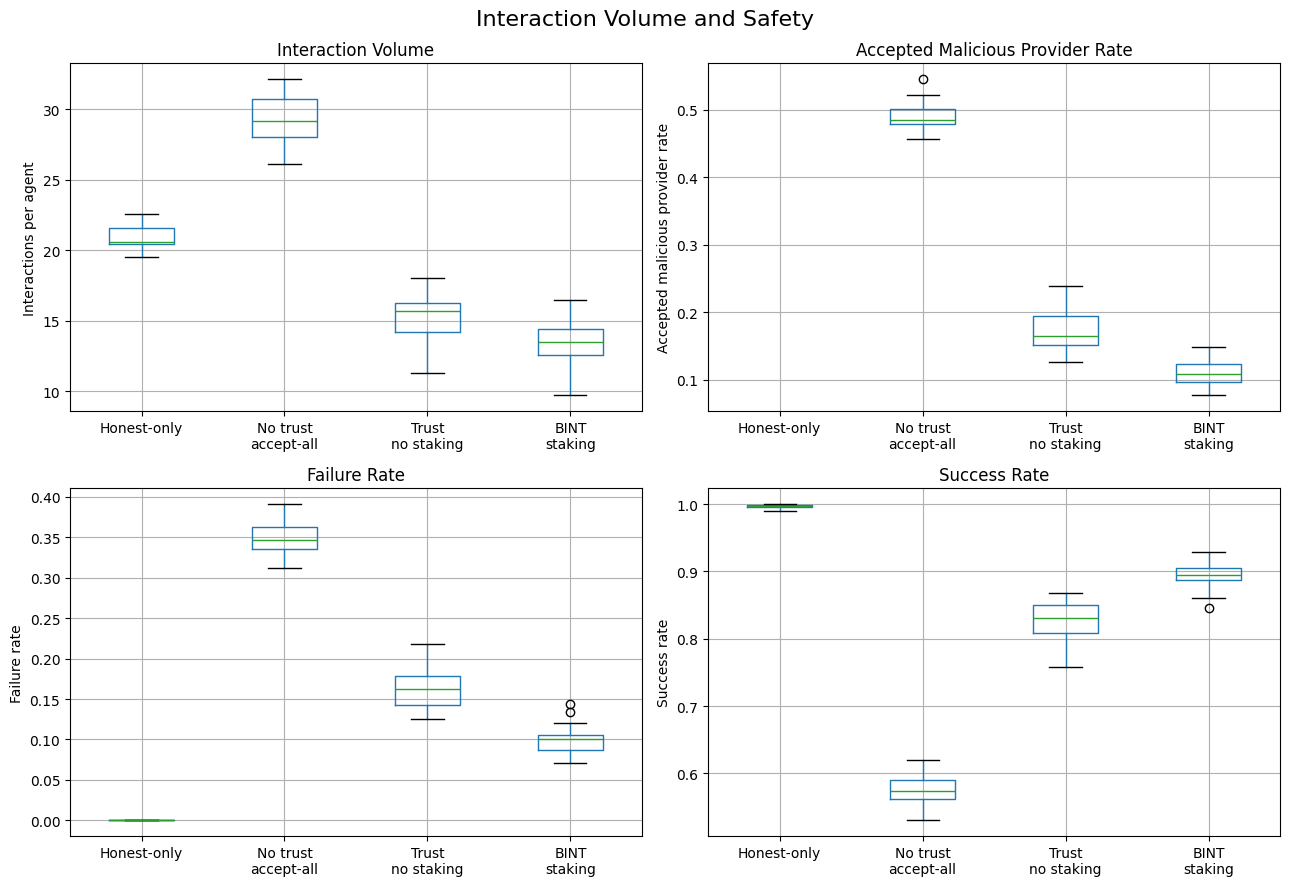

In [86]:
# -------------------------------------------------------------------
# Figure: interaction safety summary
# -------------------------------------------------------------------

def boxplot_by_scenario(
    ax,
    df: pd.DataFrame,
    metric: str,
    title: str,
    ylabel: str,
):
    plot_df = df.dropna(subset=[metric]).copy()
    plot_df = plot_df.sort_values("scenario_label")

    plot_df.boxplot(
        column=metric,
        by="scenario_label",
        ax=ax,
        rot=0,
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

boxplot_by_scenario(
    axes[0],
    interaction_final_df,
    "interactions_per_agent",
    "Interaction Volume",
    "Interactions per agent",
)

boxplot_by_scenario(
    axes[1],
    interaction_final_df,
    "accepted_malicious_provider_rate",
    "Accepted Malicious Provider Rate",
    "Accepted malicious provider rate",
)

boxplot_by_scenario(
    axes[2],
    interaction_final_df,
    "failure_rate",
    "Failure Rate",
    "Failure rate",
)

boxplot_by_scenario(
    axes[3],
    interaction_final_df,
    "success_rate",
    "Success Rate",
    "Success rate",
)

fig.suptitle("Interaction Volume and Safety", fontsize=16)
fig.tight_layout()

save_current_figure("interaction_safety_summary_2x2.png")
plt.show()

In [87]:
# -------------------------------------------------------------------
# Accepted provider composition table
# -------------------------------------------------------------------

provider_composition_cols = [
    "accepted_honest_provider_per_agent",
    "accepted_malicious_provider_per_agent",
    "accepted_honest_provider_rate",
    "accepted_malicious_provider_rate",
]

provider_composition_table = (
    interaction_final_df
    .groupby("config")[
        [col for col in provider_composition_cols if col in interaction_final_df.columns]
    ]
    .mean()
    .reindex(SCENARIO_ORDER)
    .rename(index=SCENARIO_LABELS)
    .round(3)
)

display(provider_composition_table)

,accepted_honest_provider_per_agent,accepted_malicious_provider_per_agent,accepted_honest_provider_rate,accepted_malicious_provider_rate
config,,,,
Honest-only,20.887,NaN,1.000,NaN
No trust\naccept-all,14.912,14.368,0.510,0.490
Trust\nno staking,12.775,2.595,0.828,0.172
BINT\nstaking,11.930,1.443,0.890,0.110


Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/accepted_provider_composition.png


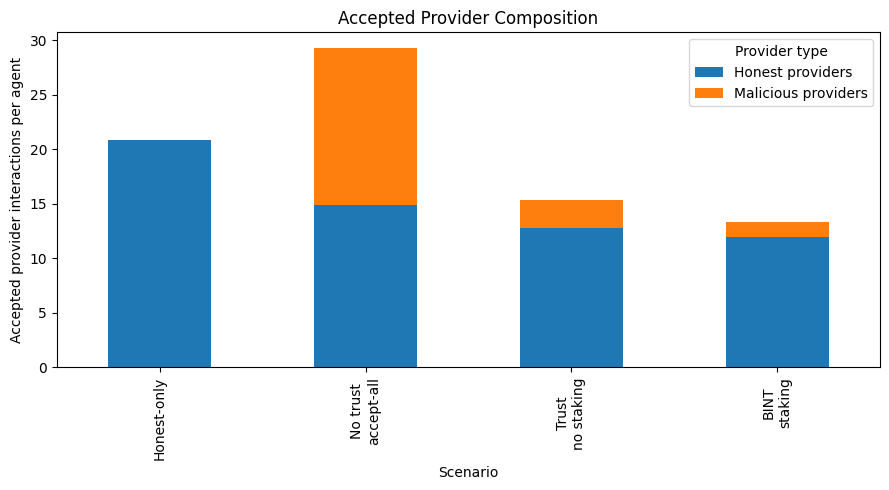

In [88]:
# -------------------------------------------------------------------
# Figure: accepted provider composition
# -------------------------------------------------------------------

provider_plot_df = (
    interaction_final_df
    .groupby("config")[
        [
            "accepted_honest_provider_per_agent",
            "accepted_malicious_provider_per_agent",
        ]
    ]
    .mean()
    .reindex(SCENARIO_ORDER)
    .rename(index=SCENARIO_LABELS)
)

provider_plot_df = provider_plot_df.fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))

provider_plot_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
)

ax.set_title("Accepted Provider Composition")
ax.set_xlabel("Scenario")
ax.set_ylabel("Accepted provider interactions per agent")
ax.legend(
    [
        "Honest providers",
        "Malicious providers",
    ],
    title="Provider type",
)

fig.tight_layout()

save_current_figure("accepted_provider_composition.png")
plt.show()

In [89]:
# -------------------------------------------------------------------
# Outcome composition table
# -------------------------------------------------------------------

outcome_composition_cols = [
    "successful_interactions_per_agent",
    "failed_interactions_per_agent",
    "success_rate",
    "failure_rate",
    "failures_per_success",
]

outcome_composition_table = (
    interaction_final_df
    .groupby("config")[
        [col for col in outcome_composition_cols if col in interaction_final_df.columns]
    ]
    .mean()
    .reindex(SCENARIO_ORDER)
    .rename(index=SCENARIO_LABELS)
    .round(3)
)

display(outcome_composition_table)

,successful_interactions_per_agent,failed_interactions_per_agent,success_rate,failure_rate,failures_per_success
config,,,,,
Honest-only,20.825,0.000,0.997,0.000,0.000
No trust\naccept-all,16.790,10.245,0.574,0.349,0.610
Trust\nno staking,12.735,2.485,0.827,0.163,0.199
BINT\nstaking,11.987,1.312,0.894,0.100,0.112


Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/interaction_outcome_composition.png


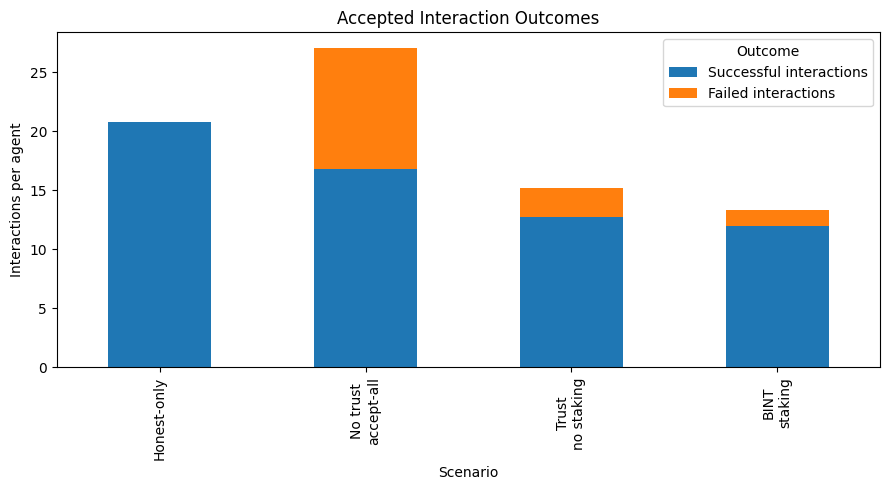

In [90]:
# -------------------------------------------------------------------
# Figure: outcome composition
# -------------------------------------------------------------------

outcome_plot_df = (
    interaction_final_df
    .groupby("config")[
        [
            "successful_interactions_per_agent",
            "failed_interactions_per_agent",
        ]
    ]
    .mean()
    .reindex(SCENARIO_ORDER)
    .rename(index=SCENARIO_LABELS)
)

fig, ax = plt.subplots(figsize=(9, 5))

outcome_plot_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
)

ax.set_title("Accepted Interaction Outcomes")
ax.set_xlabel("Scenario")
ax.set_ylabel("Interactions per agent")
ax.legend(
    [
        "Successful interactions",
        "Failed interactions",
    ],
    title="Outcome",
)

fig.tight_layout()

save_current_figure("interaction_outcome_composition.png")
plt.show()

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/interaction_trajectories_3panel.png


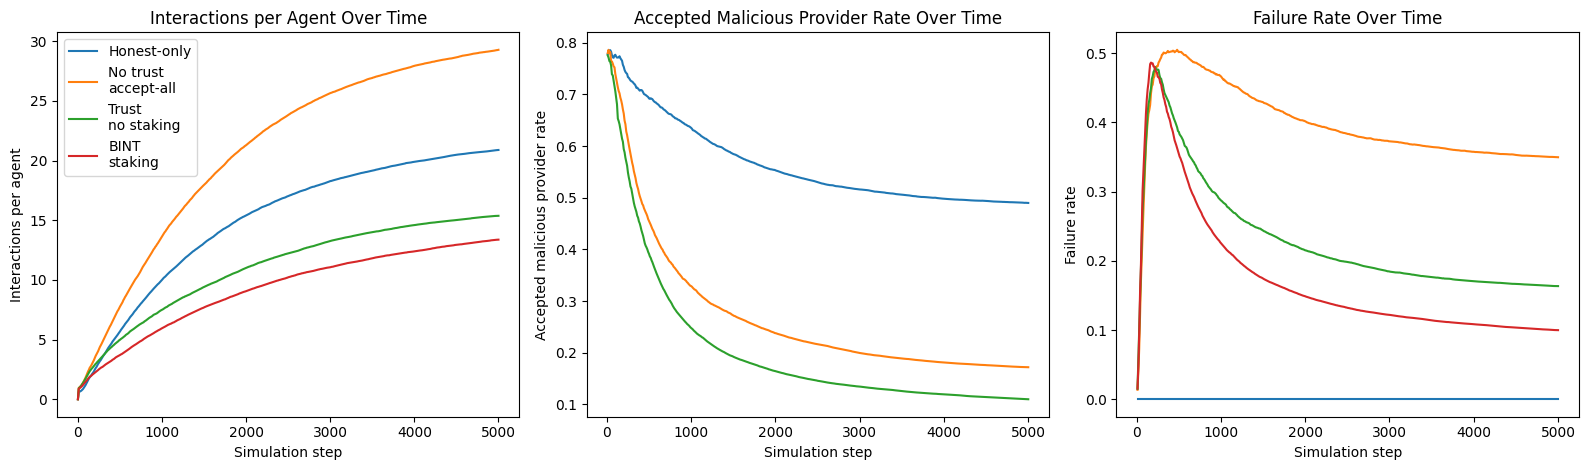

In [91]:
# -------------------------------------------------------------------
# Figure: interaction trajectories
# -------------------------------------------------------------------

trajectory_metrics = [
    (
        "interactions_per_agent",
        "Interactions per Agent Over Time",
        "Interactions per agent",
    ),
    (
        "accepted_malicious_provider_rate",
        "Accepted Malicious Provider Rate Over Time",
        "Accepted malicious provider rate",
    ),
    (
        "failure_rate",
        "Failure Rate Over Time",
        "Failure rate",
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

for ax, (metric, title, ylabel) in zip(axes, trajectory_metrics):
    plot_df = (
        interaction_trajectory_df
        .dropna(subset=[metric])
        .groupby(["scenario_label", "sim_step"], as_index=False)[metric]
        .mean()
        .sort_values(["scenario_label", "sim_step"])
    )

    for label, scenario_df in plot_df.groupby("scenario_label"):
        ax.plot(
            scenario_df["sim_step"],
            scenario_df[metric],
            label=label,
        )

    ax.set_title(title)
    ax.set_xlabel("Simulation step")
    ax.set_ylabel(ylabel)

axes[0].legend()
fig.tight_layout()

save_current_figure("interaction_trajectories_3panel.png")
plt.show()

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/interaction_volume_vs_failure_rate.png


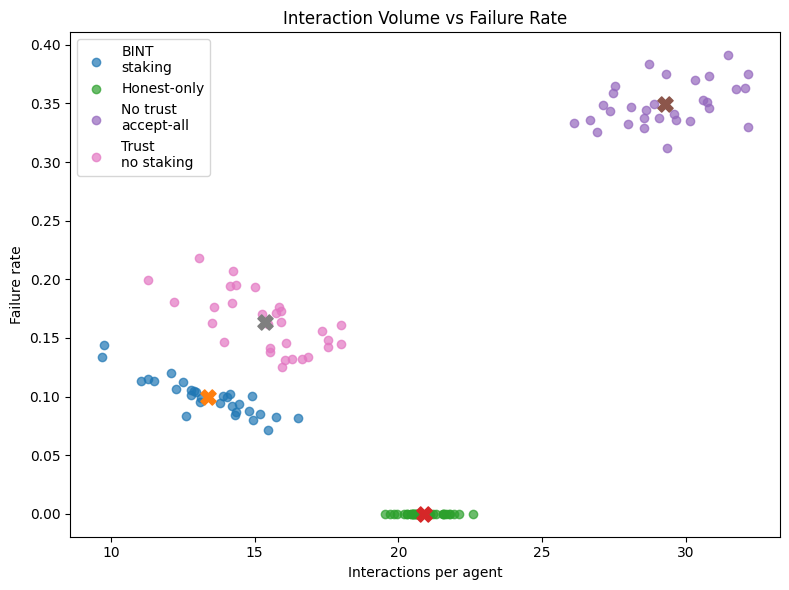

In [92]:
# -------------------------------------------------------------------
# Figure: safety-performance tradeoff
# -------------------------------------------------------------------

tradeoff_df = interaction_final_df.copy()

fig, ax = plt.subplots(figsize=(8, 6))

for config_name, config_df in tradeoff_df.groupby("config"):
    label = SCENARIO_LABELS.get(config_name, config_name)

    ax.scatter(
        config_df["interactions_per_agent"],
        config_df["failure_rate"],
        alpha=0.7,
        label=label,
    )

    ax.scatter(
        config_df["interactions_per_agent"].mean(),
        config_df["failure_rate"].mean(),
        marker="X",
        s=120,
    )

ax.set_title("Interaction Volume vs Failure Rate")
ax.set_xlabel("Interactions per agent")
ax.set_ylabel("Failure rate")
ax.legend()
fig.tight_layout()

save_current_figure("interaction_volume_vs_failure_rate.png")
plt.show()

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/interaction_volume_vs_malicious_provider_rate.png


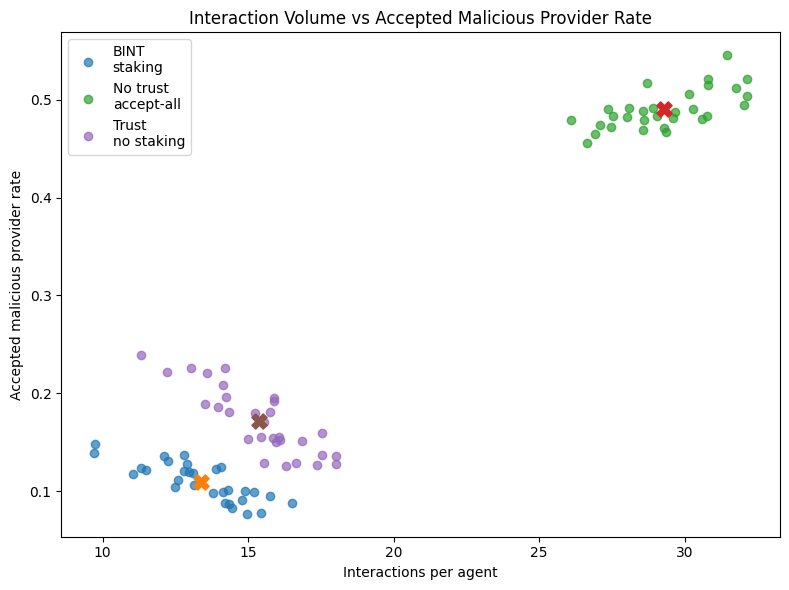

In [93]:
# -------------------------------------------------------------------
# Figure: interaction volume vs accepted malicious provider rate
# -------------------------------------------------------------------

malicious_tradeoff_df = interaction_final_df[
    interaction_final_df["malicious_agents"] > 0
].copy()

fig, ax = plt.subplots(figsize=(8, 6))

for config_name, config_df in malicious_tradeoff_df.groupby("config"):
    label = SCENARIO_LABELS.get(config_name, config_name)

    ax.scatter(
        config_df["interactions_per_agent"],
        config_df["accepted_malicious_provider_rate"],
        alpha=0.7,
        label=label,
    )

    ax.scatter(
        config_df["interactions_per_agent"].mean(),
        config_df["accepted_malicious_provider_rate"].mean(),
        marker="X",
        s=120,
    )

ax.set_title("Interaction Volume vs Accepted Malicious Provider Rate")
ax.set_xlabel("Interactions per agent")
ax.set_ylabel("Accepted malicious provider rate")
ax.legend()
fig.tight_layout()

save_current_figure("interaction_volume_vs_malicious_provider_rate.png")
plt.show()

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/accepted_provider_composition_boxplot.png


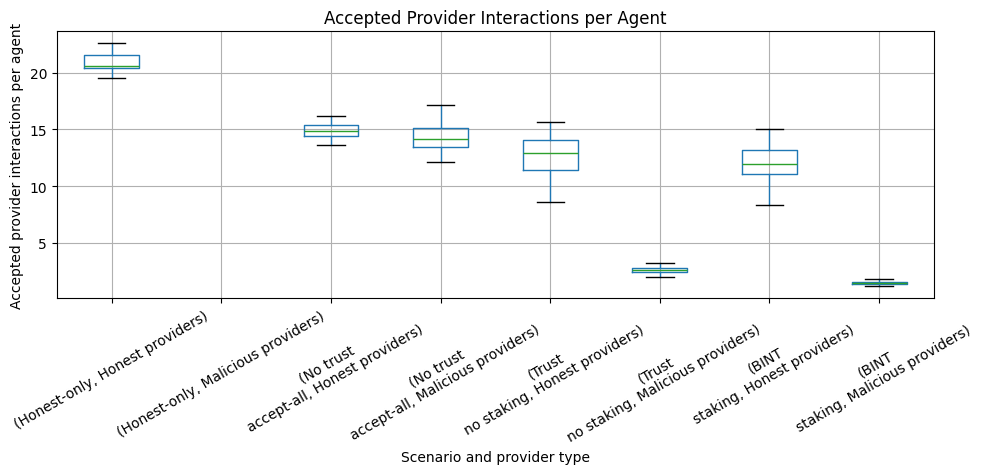

In [94]:
# -------------------------------------------------------------------
# Boxplot version: accepted providers per agent by provider type
# -------------------------------------------------------------------

provider_long_df = interaction_final_df[
    [
        "scenario_label",
        "accepted_honest_provider_per_agent",
        "accepted_malicious_provider_per_agent",
    ]
].copy()

provider_long_df = provider_long_df.melt(
    id_vars="scenario_label",
    value_vars=[
        "accepted_honest_provider_per_agent",
        "accepted_malicious_provider_per_agent",
    ],
    var_name="provider_type",
    value_name="accepted_providers_per_agent",
)

provider_long_df["provider_type"] = provider_long_df["provider_type"].map(
    {
        "accepted_honest_provider_per_agent": "Honest providers",
        "accepted_malicious_provider_per_agent": "Malicious providers",
    }
)

provider_long_df = provider_long_df.dropna(subset=["accepted_providers_per_agent"])

fig, ax = plt.subplots(figsize=(10, 5))

provider_long_df.boxplot(
    column="accepted_providers_per_agent",
    by=["scenario_label", "provider_type"],
    ax=ax,
    rot=30,
)

ax.set_title("Accepted Provider Interactions per Agent")
ax.set_xlabel("Scenario and provider type")
ax.set_ylabel("Accepted provider interactions per agent")
fig.suptitle("")
fig.tight_layout()

save_current_figure("accepted_provider_composition_boxplot.png")
plt.show()

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/interaction_outcome_composition_boxplot.png


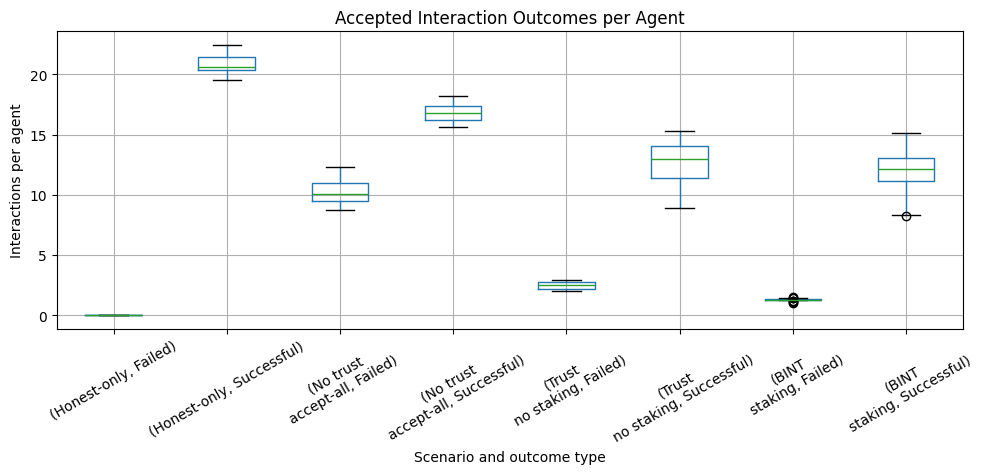

In [95]:
# -------------------------------------------------------------------
# Boxplot version: successful vs failed interactions per agent
# -------------------------------------------------------------------

outcome_long_df = interaction_final_df[
    [
        "scenario_label",
        "successful_interactions_per_agent",
        "failed_interactions_per_agent",
    ]
].copy()

outcome_long_df = outcome_long_df.melt(
    id_vars="scenario_label",
    value_vars=[
        "successful_interactions_per_agent",
        "failed_interactions_per_agent",
    ],
    var_name="outcome_type",
    value_name="interactions_per_agent",
)

outcome_long_df["outcome_type"] = outcome_long_df["outcome_type"].map(
    {
        "successful_interactions_per_agent": "Successful",
        "failed_interactions_per_agent": "Failed",
    }
)

fig, ax = plt.subplots(figsize=(10, 5))

outcome_long_df.boxplot(
    column="interactions_per_agent",
    by=["scenario_label", "outcome_type"],
    ax=ax,
    rot=30,
)

ax.set_title("Accepted Interaction Outcomes per Agent")
ax.set_xlabel("Scenario and outcome type")
ax.set_ylabel("Interactions per agent")
fig.suptitle("")
fig.tight_layout()

save_current_figure("interaction_outcome_composition_boxplot.png")
plt.show()

In [97]:
# -------------------------------------------------------------------
# Harm reduction relative to no-trust baseline
# -------------------------------------------------------------------

baseline = "no_trust_accept_all_medium_attack"

harm_metrics = [
    "accepted_malicious_provider_rate",
    "failure_rate",
    "accepted_malicious_provider_per_agent",
    "failed_interactions_per_agent",
]

means = (
    interaction_final_df
    .groupby("config")[
        [m for m in harm_metrics if m in interaction_final_df.columns]
    ]
    .mean()
)

baseline_values = means.loc[baseline]

harm_reduction_table = (
    (baseline_values - means)
    .divide(baseline_values)
    .mul(100)
    .round(1)
)

display(
    harm_reduction_table
    .rename(index=SCENARIO_LABELS)
)

,accepted_malicious_provider_rate,failure_rate,accepted_malicious_provider_per_agent,failed_interactions_per_agent
config,,,,
BINT\nstaking,77.6,71.5,90.0,87.2
Honest-only,NaN,100.0,NaN,100.0
No trust\naccept-all,0.0,0.0,0.0,0.0
Trust\nno staking,64.9,53.2,81.9,75.7


In [98]:
# -------------------------------------------------------------------
# BINT improvement relative to trust without staking
# -------------------------------------------------------------------

trust_only = "trust_no_staking_medium_attack"
bint = "bint_staking_medium_attack"

staking_effect_metrics = [
    "interactions_per_agent",
    "accepted_malicious_provider_rate",
    "failure_rate",
    "accepted_malicious_provider_per_agent",
    "failed_interactions_per_agent",
    "success_rate",
]

staking_effect = pd.DataFrame(
    {
        "trust_no_staking": means.reindex([trust_only]).iloc[0]
        if False else interaction_final_df.groupby("config")[staking_effect_metrics].mean().loc[trust_only],
        "bint_staking": interaction_final_df.groupby("config")[staking_effect_metrics].mean().loc[bint],
    }
)

staking_effect["absolute_change_bint_minus_trust_only"] = (
    staking_effect["bint_staking"] - staking_effect["trust_no_staking"]
)

staking_effect["percent_change_vs_trust_only"] = (
    staking_effect["absolute_change_bint_minus_trust_only"]
    / staking_effect["trust_no_staking"]
    * 100
)

display(staking_effect.round(3))

,trust_no_staking,bint_staking,absolute_change_bint_minus_trust_only,percent_change_vs_trust_only
interactions_per_agent,15.370,13.373,-1.997,-12.991
accepted_malicious_provider_rate,0.172,0.110,-0.062,-36.091
failure_rate,0.163,0.100,-0.064,-38.936
accepted_malicious_provider_per_agent,2.595,1.443,-1.152,-44.380
failed_interactions_per_agent,2.485,1.312,-1.173,-47.217
success_rate,0.827,0.894,0.068,8.198


Interaction and outcome analysis

The third part of the evaluation examines whether BINT changes the safety and quality of accepted interactions. This is important because a trust system should not only assign meaningful scores or affect reward distribution; it should also influence which interactions actually take place. The main question in this section is whether BINT reduces harmful accepted interactions while still preserving useful cooperation.

This question is different from simply asking whether BINT maximizes the total number of interactions. A system can allow many interactions and still be unsafe if many of those interactions involve malicious providers or lead to failed outcomes. Therefore, the evaluation considers interaction volume together with interaction quality. The main metrics are interactions per agent, accepted malicious provider rate, failure rate, success rate, accepted provider composition, and outcome composition.

The no-trust accept-all baseline produces the highest interaction volume, with 29.280 interactions per agent. This is substantially higher than the trust-without-staking scenario, which has 15.370 interactions per agent, and the full BINT scenario, which has 13.373 interactions per agent. However, this higher volume does not indicate better system behaviour. In the no-trust baseline, 49.0% of accepted providers are malicious, and the failure rate is 34.9%. This shows that unrestricted interaction creates many opportunities, but a large portion of those opportunities are harmful or unreliable.

Trust without staking improves interaction safety substantially. The accepted malicious provider rate falls from 0.490 in the no-trust baseline to 0.172, and the failure rate falls from 0.349 to 0.163. This shows that trust filtering alone helps agents avoid harmful providers. However, malicious providers are still accepted at a noticeable rate, and accepted interactions still fail more often than in the full BINT scenario.

The full BINT model produces the safest accepted interactions among the attack scenarios. In BINT, the accepted malicious provider rate falls to 0.110, and the failure rate falls to 0.100. The success rate rises to 0.894, compared with 0.827 for trust without staking and 0.574 for no trust. This means that BINT accepts fewer interactions overall, but the interactions it does accept are more reliable. The result is not higher interaction quantity, but higher interaction safety.

The accepted provider composition explains this result more clearly. In the no-trust baseline, accepted provider interactions are almost evenly split between honest and malicious providers: 14.912 accepted honest-provider interactions per agent and 14.368 accepted malicious-provider interactions per agent. This means malicious agents are allowed to act as providers almost as often as honest agents. In the trust-without-staking scenario, accepted malicious-provider interactions fall to 2.595 per agent. In the full BINT scenario, they fall further to 1.443 per agent. Therefore, BINT strongly reduces the ability of malicious agents to remain active providers in accepted interactions.

The outcome composition shows the same pattern from the perspective of success and failure. The no-trust baseline produces 16.790 successful interactions per agent, but also 10.245 failed interactions per agent. Trust without staking reduces failed interactions to 2.485 per agent. BINT reduces them further to 1.312 per agent. Although BINT has fewer total interactions than the no-trust baseline, it avoids most of the failed interactions that occur when malicious providers are accepted freely.

The harm-reduction table makes the difference especially clear. Relative to the no-trust accept-all baseline, BINT reduces the accepted malicious provider rate by 77.6%, the failure rate by 71.5%, accepted malicious-provider interactions per agent by 90.0%, and failed interactions per agent by 87.2%. Trust without staking also improves safety, but the reductions are smaller: 64.9% for accepted malicious provider rate, 53.2% for failure rate, 81.9% for accepted malicious-provider interactions per agent, and 75.7% for failed interactions per agent. This suggests that trust filtering is useful, but the full BINT mechanism provides stronger protection.

The comparison between trust without staking and BINT isolates the effect of staking. Adding staking reduces interactions per agent by 13.0%, from 15.370 to 13.373. However, this reduction is accompanied by a 36.1% decrease in accepted malicious provider rate, a 38.9% decrease in failure rate, a 44.4% decrease in accepted malicious-provider interactions per agent, and a 47.2% decrease in failed interactions per agent. The success rate also increases by 8.2%. This indicates that staking introduces a cost to unrestricted interaction, but that cost is associated with substantially safer accepted interactions.

The trajectory plots show that these differences are not only final-state effects. The no-trust baseline maintains the highest interaction rate throughout the simulation, but its accepted malicious provider rate and failure rate remain much higher than the trust-based scenarios. In contrast, BINT’s accepted malicious provider rate and failure rate decline more strongly over time. This suggests that BINT progressively filters harmful interaction opportunities as trust and staking evidence accumulate.

Overall, the interaction results support the central claim that BINT improves interaction safety rather than simply increasing interaction volume. The no-trust baseline allows the most interactions, but nearly half of accepted providers are malicious and over one-third of interactions fail. Trust without staking reduces harmful interactions, showing that trust evidence is useful. BINT with staking reduces them further, producing the lowest malicious-provider acceptance rate, the lowest failure rate, and the highest success rate among the attack scenarios. Therefore, BINT trades some unrestricted interaction volume for safer and more selective cooperation.

Suggested figure captions

Figure X. Interaction volume and safety.
This figure compares interaction volume, accepted malicious provider rate, failure rate, and success rate across scenarios. The no-trust baseline allows the most interactions, but also has the highest malicious-provider acceptance and failure rate. BINT allows fewer interactions, but produces the safest accepted interactions among the attack scenarios.

Figure X. Accepted provider composition.
This figure shows accepted provider interactions per agent, separated by provider type. In the no-trust baseline, malicious providers are accepted almost as often as honest providers. Trust filtering reduces this substantially, and BINT with staking produces the lowest malicious-provider component.

Figure X. Accepted interaction outcomes.
This figure separates accepted interactions into successful and failed outcomes. The no-trust baseline produces many successful interactions, but also many failed interactions. BINT has fewer total interactions, but far fewer failures.

Figure X. Interaction metrics over time.
This figure shows interactions per agent, accepted malicious provider rate, and failure rate throughout the simulation. The no-trust baseline maintains high interaction volume but also high harmful interaction rates. BINT reduces accepted malicious providers and failures over time.

Figure X. Interaction volume versus failure rate.
This figure shows the tradeoff between interaction quantity and interaction safety. The no-trust baseline clusters at high interaction volume but high failure rate. BINT clusters at lower interaction volume but much lower failure rate.

Figure X. Interaction volume versus accepted malicious provider rate.
This figure shows the relationship between interaction volume and malicious-provider acceptance. The no-trust baseline combines high interaction volume with high malicious-provider acceptance, while BINT substantially lowers malicious-provider acceptance.

In [ ]:
# -------------------------------------------------------------------
# Mechanism ablation comparison data
# -------------------------------------------------------------------

ablation_final_df = interaction_final_df.copy()

# Make sure labels/order are present.
ablation_final_df = add_scenario_labels(ablation_final_df)

# Clean malicious-specific values for honest-only.
no_malicious = ablation_final_df["malicious_agents"] == 0

malicious_specific_cols = [
    "points_per_malicious_agent",
    "malicious_points_per_delivery",
    "points_gap_honest_minus_malicious",
    "avg_trust_malicious",
    "trust_gap_honest_minus_malicious",
    "accepted_malicious_provider_rate",
    "accepted_malicious_provider_per_agent",
    "malicious_burns_per_malicious_agent",
    "malicious_burn_share",
]

for col in malicious_specific_cols:
    if col in ablation_final_df.columns:
        ablation_final_df.loc[no_malicious, col] = np.nan

AttributeError: 'str' object has no attribute 'suffix'

In [100]:
# -------------------------------------------------------------------
# Main mechanism ablation table
# -------------------------------------------------------------------

ABLATION_METRICS = [
    "points_per_honest_agent",
    "points_per_malicious_agent",
    "points_gap_honest_minus_malicious",
    "interactions_per_agent",
    "success_rate",
    "failure_rate",
    "accepted_malicious_provider_rate",
    "accepted_malicious_provider_per_agent",
    "avg_trust_honest",
    "avg_trust_malicious",
    "trust_gap_honest_minus_malicious",
]

ablation_table = (
    ablation_final_df
    .groupby("config")[
        [metric for metric in ABLATION_METRICS if metric in ablation_final_df.columns]
    ]
    .mean()
    .reindex(SCENARIO_ORDER)
    .rename(index=SCENARIO_LABELS)
    .round(3)
)

display(ablation_table)

,points_per_honest_agent,points_per_malicious_agent,points_gap_honest_minus_malicious,interactions_per_agent,success_rate,failure_rate,accepted_malicious_provider_rate,accepted_malicious_provider_per_agent,avg_trust_honest,avg_trust_malicious,trust_gap_honest_minus_malicious
config,,,,,,,,,,,
Honest-only,682.636,NaN,NaN,20.887,0.997,0.000,NaN,NaN,0.957,NaN,NaN
No trust\naccept-all,531.690,547.767,-16.077,29.280,0.574,0.349,0.490,14.368,0.803,0.231,0.572
Trust\nno staking,521.913,35.271,486.643,15.370,0.827,0.163,0.172,2.595,0.914,0.267,0.647
BINT\nstaking,497.626,-1.294,498.921,13.373,0.894,0.100,0.110,1.443,0.904,0.278,0.626


In [101]:
# -------------------------------------------------------------------
# Ablation table with mean and standard deviation
# -------------------------------------------------------------------

ablation_table_mean_std = (
    ablation_final_df
    .groupby("config")[
        [metric for metric in ABLATION_METRICS if metric in ablation_final_df.columns]
    ]
    .agg(["mean", "std"])
    .reindex(SCENARIO_ORDER)
    .rename(index=SCENARIO_LABELS)
    .round(3)
)

display(ablation_table_mean_std)

points_per_honest_agent          points_per_malicious_agent         points_gap_honest_minus_malicious          interactions_per_agent        success_rate        failure_rate  \
                                        mean      std                       mean     std                              mean      std                   mean    std         mean    std         mean   
config                                                                                                                                                                                               
Honest-only                          682.636   42.774                        NaN     NaN                               NaN      NaN                 20.887  0.764        0.997  0.003        0.000   
No trust\naccept-all                 531.690   49.467                    547.767  47.557                           -16.077   33.033                 29.280  1.743        0.574  0.022        0.349   
Trust\nno staking                    521.913  125.265                     35.271  58.344                           486.643  112.452                 15.370  1.663        0.827  0.028        0.163   
BINT\nstaking                        497.626  128.109                     -1.294  14.616                           498.921  127.053                 13.373  1.665        0.894  0.018        0.100   

                            accepted_malicious_provider_rate        accepted_malicious_provider_per_agent        avg_trust_honest        avg_trust_malicious        trust_gap_honest_minus_malicious  \
                        std                             mean    std                                  mean    std             mean    std                mean    std                             mean   
config                                                                                                                                                                                                 
Honest-only           0.000                              NaN    NaN                                   NaN    NaN            0.957  0.001                 NaN    NaN                              NaN   
No trust\naccept-all  0.019                            0.490  0.020                                14.368  1.326            0.803  0.020               0.231  0.040                            0.572   
Trust\nno staking     0.025                            0.172  0.034                                 2.595  0.311            0.914  0.019               0.267  0.032                            0.647   
BINT\nstaking         0.016                            0.110  0.020                                 1.443  0.162            0.904  0.020               0.278  0.018                            0.626   

                             
                        std  
config                       
Honest-only             NaN  
No trust\naccept-all  0.044  
Trust\nno staking     0.045  
BINT\nstaking         0.024

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/mechanism_ablation_summary_2x2.png


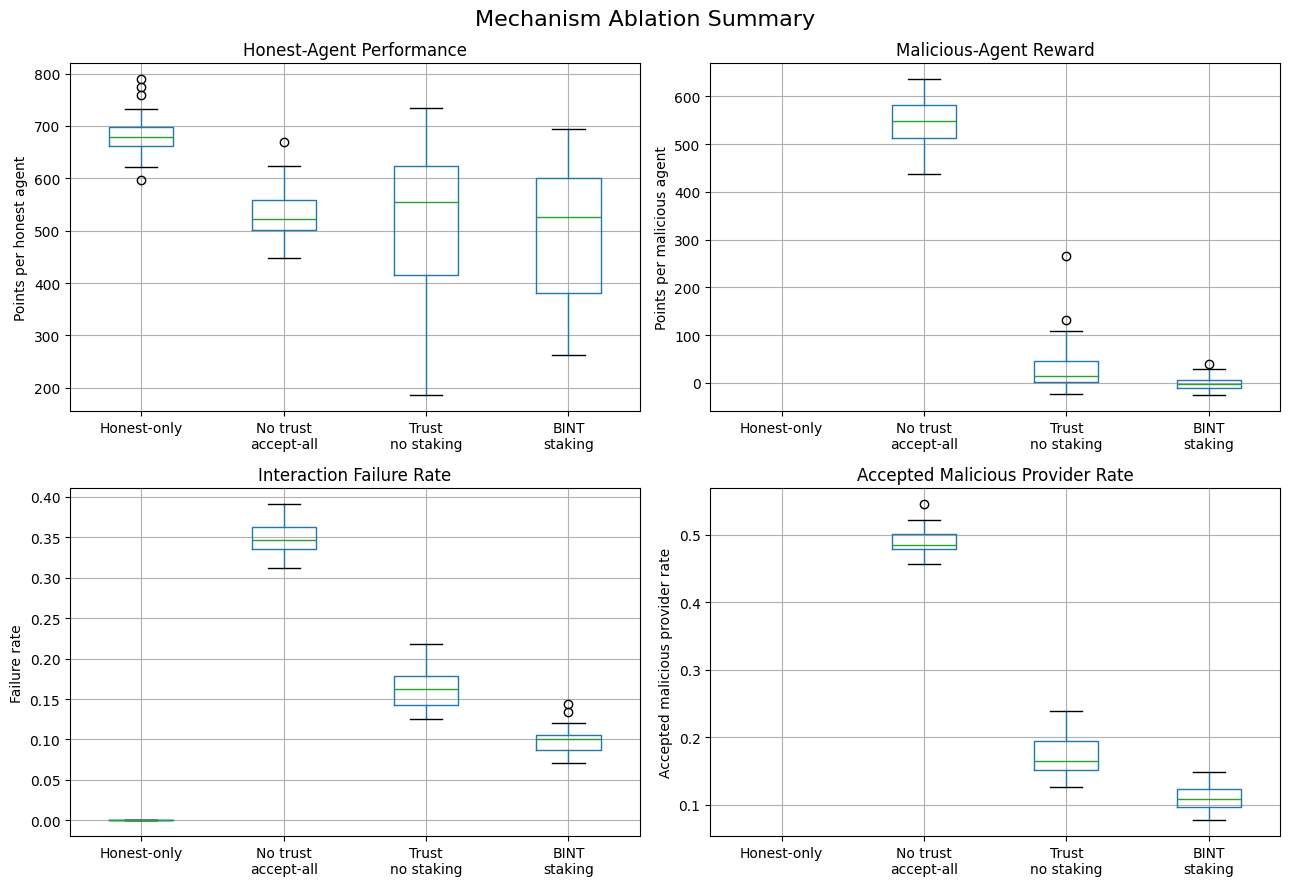

In [102]:
# -------------------------------------------------------------------
# Figure: mechanism ablation summary
# -------------------------------------------------------------------

def boxplot_by_scenario(
    ax,
    df: pd.DataFrame,
    metric: str,
    title: str,
    ylabel: str,
):
    plot_df = df.dropna(subset=[metric]).copy()
    plot_df = plot_df.sort_values("scenario_label")

    plot_df.boxplot(
        column=metric,
        by="scenario_label",
        ax=ax,
        rot=0,
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

boxplot_by_scenario(
    axes[0],
    ablation_final_df,
    "points_per_honest_agent",
    "Honest-Agent Performance",
    "Points per honest agent",
)

boxplot_by_scenario(
    axes[1],
    ablation_final_df,
    "points_per_malicious_agent",
    "Malicious-Agent Reward",
    "Points per malicious agent",
)

boxplot_by_scenario(
    axes[2],
    ablation_final_df,
    "failure_rate",
    "Interaction Failure Rate",
    "Failure rate",
)

boxplot_by_scenario(
    axes[3],
    ablation_final_df,
    "accepted_malicious_provider_rate",
    "Accepted Malicious Provider Rate",
    "Accepted malicious provider rate",
)

fig.suptitle("Mechanism Ablation Summary", fontsize=16)
fig.tight_layout()

save_current_figure("mechanism_ablation_summary_2x2.png")
plt.show()

In [103]:
# -------------------------------------------------------------------
# Mechanism contribution table
# -------------------------------------------------------------------

attack_scenarios = [
    "no_trust_accept_all_medium_attack",
    "trust_no_staking_medium_attack",
    "bint_staking_medium_attack",
]

contribution_metrics = [
    "points_per_honest_agent",
    "points_per_malicious_agent",
    "interactions_per_agent",
    "success_rate",
    "failure_rate",
    "accepted_malicious_provider_rate",
    "accepted_malicious_provider_per_agent",
    "failed_interactions_per_agent",
    "trust_gap_honest_minus_malicious",
]

contribution_means = (
    ablation_final_df
    .groupby("config")[
        [m for m in contribution_metrics if m in ablation_final_df.columns]
    ]
    .mean()
    .reindex(attack_scenarios)
)

contribution_table = contribution_means.rename(index=SCENARIO_LABELS).round(3)

display(contribution_table)

,points_per_honest_agent,points_per_malicious_agent,interactions_per_agent,success_rate,failure_rate,accepted_malicious_provider_rate,accepted_malicious_provider_per_agent,failed_interactions_per_agent,trust_gap_honest_minus_malicious
config,,,,,,,,,
No trust\naccept-all,531.690,547.767,29.280,0.574,0.349,0.490,14.368,10.245,0.572
Trust\nno staking,521.913,35.271,15.370,0.827,0.163,0.172,2.595,2.485,0.647
BINT\nstaking,497.626,-1.294,13.373,0.894,0.100,0.110,1.443,1.312,0.626


In [ ]:
# -------------------------------------------------------------------
# Relative changes between mechanism layers
# -------------------------------------------------------------------

def percent_change(new, old):
    return (new - old) / old * 100


no_trust = contribution_means.loc["no_trust_accept_all_medium_attack"]
trust_only = contribution_means.loc["trust_no_staking_medium_attack"]
bint = contribution_means.loc["bint_staking_medium_attack"]

relative_change_table = pd.DataFrame(
    {
        "trust_no_staking_vs_no_trust_percent": percent_change(trust_only, no_trust),
        "bint_vs_trust_no_staking_percent": percent_change(bint, trust_only),
        "bint_vs_no_trust_percent": percent_change(bint, no_trust),
    }
).round(1)

display(relative_change_table)

,trust_no_staking_vs_no_trust_percent,bint_vs_trust_no_staking_percent,bint_vs_no_trust_percent
points_per_honest_agent,-1.8,-4.7,-6.4
points_per_malicious_agent,-93.6,-103.7,-100.2
interactions_per_agent,-47.5,-13.0,-54.3
success_rate,43.9,8.2,55.7
failure_rate,-53.2,-38.9,-71.5
accepted_malicious_provider_rate,-64.9,-36.1,-77.6
accepted_malicious_provider_per_agent,-81.9,-44.4,-90.0
failed_interactions_per_agent,-75.7,-47.2,-87.2
trust_gap_honest_minus_malicious,13.0,-3.2,9.4


Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/ablation_honest_points_vs_failure_rate.png


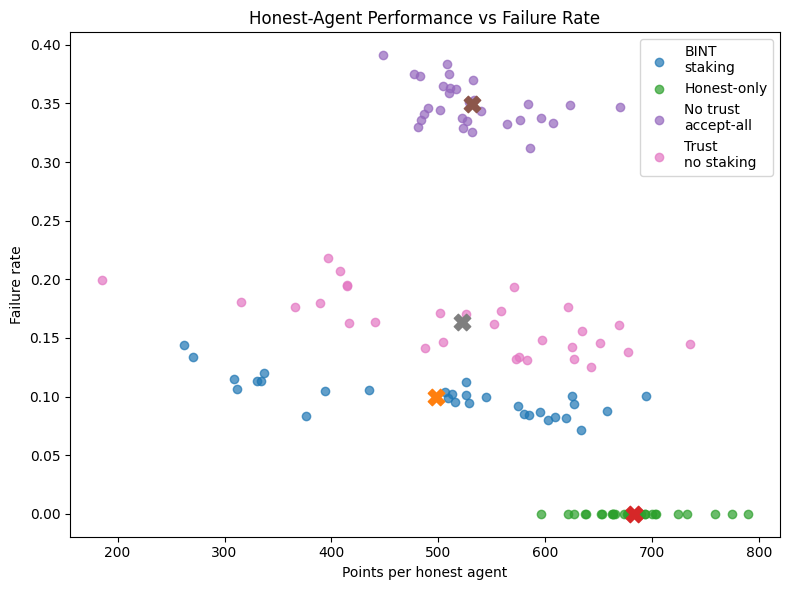

In [105]:
# -------------------------------------------------------------------
# Figure: honest performance vs failure rate
# -------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

for config_name, config_df in ablation_final_df.groupby("config"):
    label = SCENARIO_LABELS.get(config_name, config_name)

    ax.scatter(
        config_df["points_per_honest_agent"],
        config_df["failure_rate"],
        alpha=0.7,
        label=label,
    )

    ax.scatter(
        config_df["points_per_honest_agent"].mean(),
        config_df["failure_rate"].mean(),
        marker="X",
        s=140,
    )

ax.set_title("Honest-Agent Performance vs Failure Rate")
ax.set_xlabel("Points per honest agent")
ax.set_ylabel("Failure rate")
ax.legend()
fig.tight_layout()

save_current_figure("ablation_honest_points_vs_failure_rate.png")
plt.show()

Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/ablation_reward_gap_vs_malicious_provider_rate.png


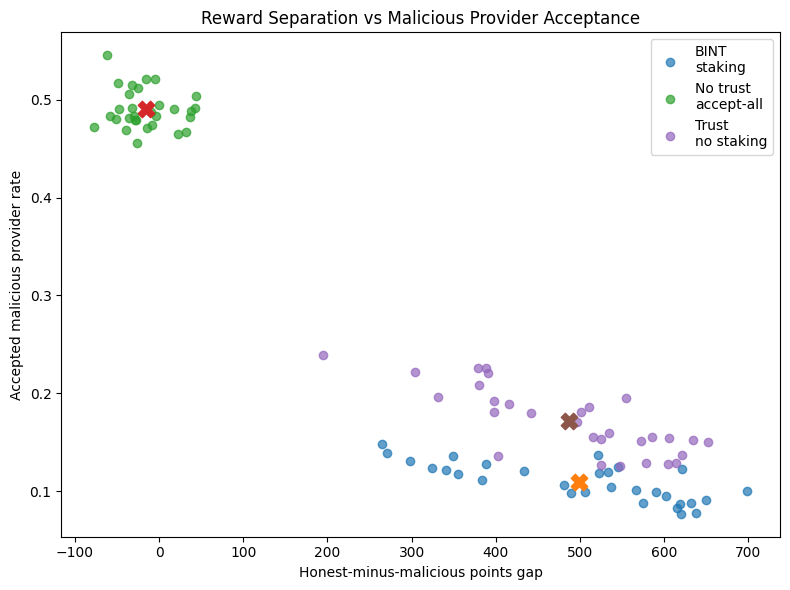

In [106]:
# -------------------------------------------------------------------
# Figure: reward separation vs malicious-provider acceptance
# -------------------------------------------------------------------

attack_only_df = ablation_final_df[
    ablation_final_df["malicious_agents"] > 0
].copy()

fig, ax = plt.subplots(figsize=(8, 6))

for config_name, config_df in attack_only_df.groupby("config"):
    label = SCENARIO_LABELS.get(config_name, config_name)

    ax.scatter(
        config_df["points_gap_honest_minus_malicious"],
        config_df["accepted_malicious_provider_rate"],
        alpha=0.7,
        label=label,
    )

    ax.scatter(
        config_df["points_gap_honest_minus_malicious"].mean(),
        config_df["accepted_malicious_provider_rate"].mean(),
        marker="X",
        s=140,
    )

ax.set_title("Reward Separation vs Malicious Provider Acceptance")
ax.set_xlabel("Honest-minus-malicious points gap")
ax.set_ylabel("Accepted malicious provider rate")
ax.legend()
fig.tight_layout()

save_current_figure("ablation_reward_gap_vs_malicious_provider_rate.png")
plt.show()

In [107]:
# -------------------------------------------------------------------
# Key ablation comparison numbers
# -------------------------------------------------------------------

key_rows = []

def metric_mean(config_name, metric):
    return ablation_final_df.loc[
        ablation_final_df["config"] == config_name,
        metric,
    ].mean()

for metric in [
    "points_per_honest_agent",
    "points_per_malicious_agent",
    "failure_rate",
    "accepted_malicious_provider_rate",
    "interactions_per_agent",
    "success_rate",
]:
    key_rows.append(
        {
            "metric": metric,
            "honest_only": metric_mean("honest_only_upper_bound", metric),
            "no_trust": metric_mean("no_trust_accept_all_medium_attack", metric),
            "trust_no_staking": metric_mean("trust_no_staking_medium_attack", metric),
            "bint_staking": metric_mean("bint_staking_medium_attack", metric),
        }
    )

key_ablation_numbers = pd.DataFrame(key_rows).round(3)

display(key_ablation_numbers)

,metric,honest_only,no_trust,trust_no_staking,bint_staking
0,points_per_honest_agent,682.636,531.690,521.913,497.626
1,points_per_malicious_agent,NaN,547.767,35.271,-1.294
2,failure_rate,0.000,0.349,0.163,0.100
3,accepted_malicious_provider_rate,NaN,0.490,0.172,0.110
4,interactions_per_agent,20.887,29.280,15.370,13.373
5,success_rate,0.997,0.574,0.827,0.894


Saved figure to: /home/javid/Documents/int/bint/bint/evaluation_outputs/figures/mechanism_ablation_summary_2x2_clean.png


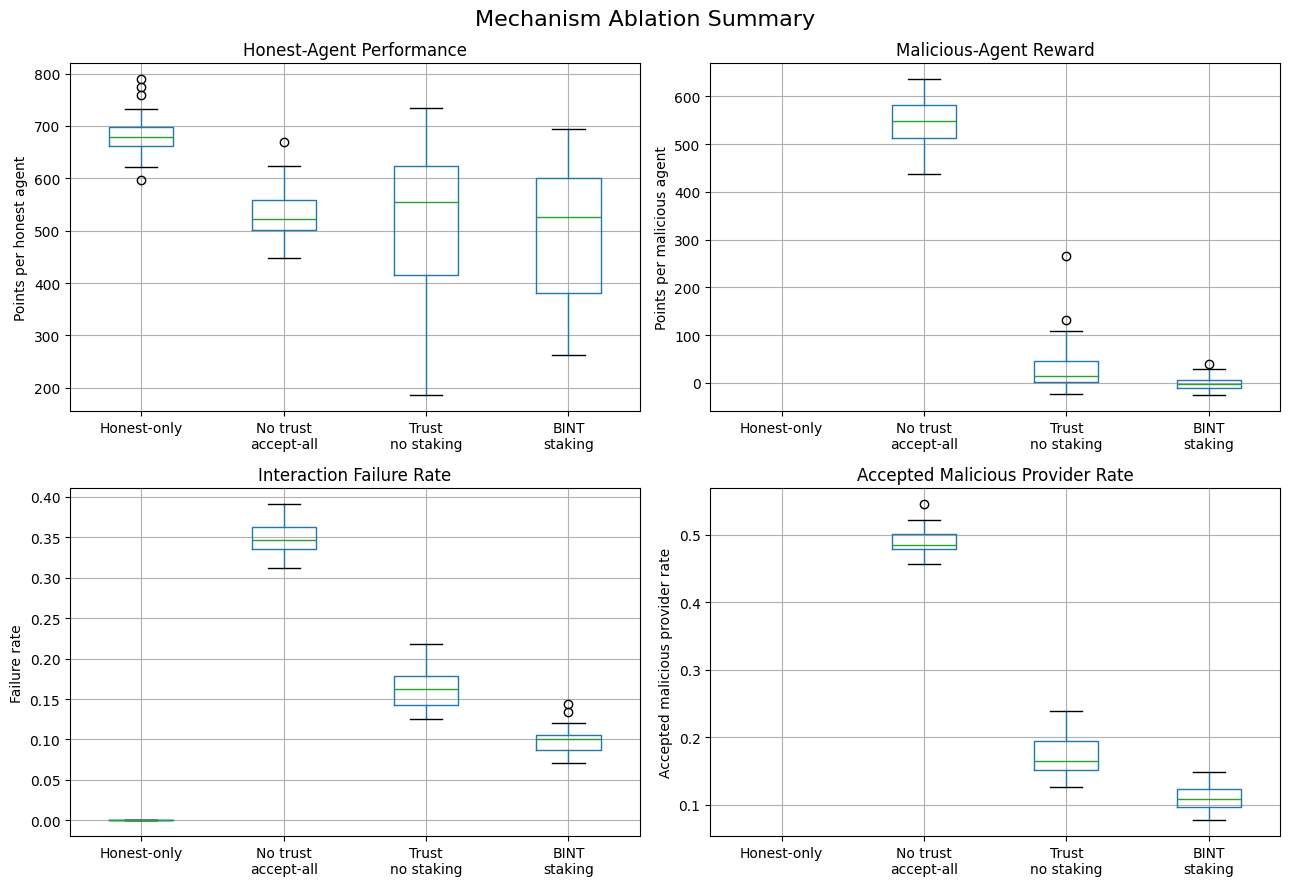

In [108]:
# -------------------------------------------------------------------
# Cleaner mechanism ablation summary figure
# Removes honest-only from malicious-specific panels.
# -------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

boxplot_by_scenario(
    axes[0],
    ablation_final_df,
    "points_per_honest_agent",
    "Honest-Agent Performance",
    "Points per honest agent",
)

boxplot_by_scenario(
    axes[1],
    ablation_final_df[ablation_final_df["malicious_agents"] > 0],
    "points_per_malicious_agent",
    "Malicious-Agent Reward",
    "Points per malicious agent",
)

boxplot_by_scenario(
    axes[2],
    ablation_final_df,
    "failure_rate",
    "Interaction Failure Rate",
    "Failure rate",
)

boxplot_by_scenario(
    axes[3],
    ablation_final_df[ablation_final_df["malicious_agents"] > 0],
    "accepted_malicious_provider_rate",
    "Accepted Malicious Provider Rate",
    "Accepted malicious provider rate",
)

fig.suptitle("Mechanism Ablation Summary", fontsize=16)
fig.tight_layout()

save_current_figure("mechanism_ablation_summary_2x2_clean.png")
plt.show()

Mechanism ablation comparison

The final comparison brings together the points, trust, and interaction results to examine what each part of the system contributes. The purpose of this section is not to introduce a new experiment, but to synthesize the previous results using the same four scenarios: an honest-only upper-bound reference, a no-trust accept-all baseline, a trust-without-staking scenario, and the full BINT model with staking.

The main question is:

What does each layer of the system contribute under malicious map-sharing behaviour?

The honest-only scenario represents the upper bound, because no malicious agents are present. The no-trust accept-all scenario shows what happens when agents interact freely under attack. The trust-without-staking scenario isolates the effect of trust filtering. The BINT scenario then shows the additional effect of bidirectional staking.

The honest-only scenario provides the expected best-case reference. Honest agents achieve 682.636 points per agent, the success rate is 0.997, and the failure rate is 0.000. This shows that, in the absence of malicious behaviour, the environment supports stable and efficient cooperation. However, this scenario should not be interpreted as an adversarial baseline, because it removes malicious agents entirely. Instead, it shows the upper-bound performance that the attack scenarios can be compared against.

The no-trust accept-all scenario shows the risk of unrestricted interaction. It has the highest interaction volume, with 29.280 interactions per agent, and honest agents still receive 531.690 points per agent. However, this apparent productivity hides severe vulnerability. Malicious agents receive 547.767 points per agent, which is slightly higher than the honest agents. The honest-minus-malicious points gap is therefore negative, at -16.077. At the same time, the accepted malicious provider rate is 0.490 and the failure rate is 0.349. This means that almost half of accepted providers are malicious, and more than one-third of accepted interactions fail. The no-trust baseline therefore maximizes interaction volume, but it does so by allowing malicious agents to participate and profit heavily.

Trust filtering substantially improves the system. In the trust-without-staking scenario, malicious points fall from 547.767 to 35.271 points per malicious agent. The failure rate falls from 0.349 to 0.163, and the accepted malicious provider rate falls from 0.490 to 0.172. Relative to the no-trust baseline, trust without staking reduces malicious reward by 93.6%, failure rate by 53.2%, accepted malicious provider rate by 64.9%, accepted malicious-provider interactions per agent by 81.9%, and failed interactions per agent by 75.7%. These results show that trust filtering alone provides a major safety improvement. Agents are no longer interacting freely with malicious providers, and malicious agents lose most of their ability to profit from the system.

The full BINT model adds staking on top of trust filtering. This produces the safest adversarial scenario. In BINT, malicious agents receive -1.294 points per agent on average, meaning that malicious participation is no longer profitable. The accepted malicious provider rate falls to 0.110, the failure rate falls to 0.100, and the success rate rises to 0.894. Compared with the no-trust baseline, BINT reduces malicious reward by approximately 100.2%, failure rate by 71.5%, accepted malicious provider rate by 77.6%, accepted malicious-provider interactions per agent by 90.0%, and failed interactions per agent by 87.2%.

The comparison between trust without staking and BINT isolates the contribution of staking. Adding staking reduces interactions per agent from 15.370 to 13.373, a decrease of 13.0%. It also reduces honest-agent points from 521.913 to 497.626, a decrease of 4.7%. Therefore, staking introduces a performance cost: agents interact slightly less and honest agents earn somewhat fewer points. However, this cost is accompanied by stronger safety outcomes. Compared with trust without staking, BINT reduces malicious points by 103.7%, accepted malicious provider rate by 36.1%, failure rate by 38.9%, accepted malicious-provider interactions per agent by 44.4%, and failed interactions per agent by 47.2%. The success rate also increases by 8.2%. This indicates that staking is not merely an extra mechanism; it improves the safety of accepted interactions by making malicious or unreliable participation less beneficial.

The trust metrics also clarify the relationship between trust and staking. Trust without staking has a slightly higher average trust gap than BINT, with a trust gap of 0.647 compared with 0.626 for BINT. This suggests that the main benefit of staking is not that it creates a larger trust-score separation. Instead, the trust mechanism already identifies malicious agents effectively. Staking changes what happens after that identification: it adds collateral risk and reduces the ability of low-trust or unreliable agents to continue benefiting from interactions. In other words, trust filtering provides the information layer, while staking provides an additional consequence layer.

The ablation comparison therefore shows a layered mechanism. Without trust, the system is highly active but unsafe. Malicious agents are accepted frequently as providers, earn high rewards, and cause many failures. With trust filtering, malicious participation and malicious reward are sharply reduced. With full BINT staking, these effects become stronger: malicious rewards fall to approximately zero or below, accepted malicious providers become less common, and failed interactions are reduced further. The tradeoff is that BINT does not maximize interaction volume or honest-agent reward. Instead, it produces the best adversarial safety tradeoff.

Overall, this comparison supports the central claim of the evaluation. BINT is not simply a productivity-maximizing mechanism. Rather, it is a trust and accountability mechanism that trades some unrestricted interaction volume for safer cooperation. It preserves reasonable honest-agent performance while sharply reducing malicious reward, malicious-provider acceptance, and failed interactions. The results show that trust filtering is valuable on its own, but that staking adds an additional layer of protection by making malicious participation less profitable and less successful.

Suggested figure captions

Figure X. Mechanism ablation summary.
This figure compares honest-agent performance, malicious-agent reward, interaction failure rate, and accepted malicious provider rate across the four scenarios. The honest-only scenario provides an upper-bound reference. The no-trust baseline allows high interaction activity but also high malicious reward and failure. Trust filtering reduces malicious benefit substantially, while BINT with staking produces the lowest malicious reward, failure rate, and malicious-provider acceptance among the adversarial scenarios.

Figure X. Honest-agent performance versus failure rate.
This figure shows the tradeoff between honest-agent reward and interaction failure. The honest-only scenario occupies the ideal upper-bound region with high honest-agent performance and no failures. The no-trust baseline maintains reasonable honest-agent points but has a high failure rate. Trust filtering and BINT reduce failures, with BINT achieving the lowest failure rate among attack scenarios.

Figure X. Reward separation versus malicious-provider acceptance.
This figure compares the honest-minus-malicious points gap with the accepted malicious provider rate. The no-trust baseline has a negative or near-zero reward gap and high malicious-provider acceptance. Trust without staking improves reward separation and reduces malicious-provider acceptance. BINT occupies the strongest region, with high reward separation and low malicious-provider acceptance.

Table X. Relative contribution of trust filtering and staking.
This table reports percentage changes between no trust, trust without staking, and BINT. Trust filtering produces the first major safety improvement by reducing malicious reward, accepted malicious providers, and failed interactions. BINT with staking further reduces harmful interactions and malicious reward, while slightly reducing interaction volume and honest-agent points.

Shorter version for the report, if needed

The ablation comparison shows that each mechanism layer contributes differently. The honest-only scenario provides an upper-bound reference, with high honest-agent points and almost no failures. The no-trust accept-all baseline has the highest interaction volume, but it is unsafe: malicious agents earn slightly more points than honest agents, almost half of accepted providers are malicious, and the failure rate is high.

Adding trust filtering substantially improves the system. Malicious-agent reward falls sharply, accepted malicious providers become less common, and the failure rate is reduced. This shows that the trust score is not only meaningful internally, but also useful for interaction decisions.

The full BINT model with staking provides the strongest adversarial safety tradeoff. Compared with trust without staking, BINT slightly reduces honest-agent points and interaction volume, but it also reduces malicious reward to approximately zero or below, lowers the accepted malicious provider rate, reduces the failure rate, and increases the success rate. This suggests that staking adds a consequence layer on top of trust filtering: trust identifies unreliable agents, while staking makes unreliable behaviour less profitable and less sustainable.

Overall, BINT does not maximize raw interaction volume. Instead, it trades some unrestricted activity for safer cooperation. This supports the central claim that BINT preserves useful honest-agent performance while reducing malicious reward, harmful accepted interactions, and failed outcomes.

In [124]:
# -------------------------------------------------------------------
# Light cleanup before scenario comparison runs
# -------------------------------------------------------------------

import gc
import matplotlib.pyplot as plt

plt.close("all")

temporary_names = [
    "provider_long_df",
    "outcome_long_df",
    "provider_plot_df",
    "outcome_plot_df",
    "tradeoff_df",
    "malicious_tradeoff_df",
    "attack_only_df",
    "relative_change_table",
    "key_rows",
    "key_ablation_numbers",
]

for name in temporary_names:
    if name in globals():
        del globals()[name]

gc.collect()

0